# Análisis exploratorio de pozos no convencionales de YPF en Vaca Muerta y su comportamiento productivo**

Grupo 3 — Primera entrega: exploración, transformación y visualización de datos con Pandas

## 1. Tema y fuentes de datos
El proyecto estudia los pozos no convencionales asociados a la formación Vaca Muerta operados por YPF, combinandoinformación técnica y operativa de los pozos con sus registros históricos mensuales de producción.Se utilizan dos fuentes de datos publicadas por la **Secretaría de Energía de la Nación**:
1. **Capítulo IV — Listado de pozos**   http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo/archivo/cb5c0f04-7835-45cd-b982-3e25ca7d7751   Contiene información descriptiva de cada pozo: área, yacimiento, profundidad, tipo de pozo, sistema de extracción,   estado y fechas de perforación y terminación. **Granularidad: una fila por pozo.**
2. **Producción de pozos de gas y petróleo no convencional**   http://datos.energia.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo/archivo/b5b58cdc-9e07-41f9-b392-fb9ec68b0725   Contiene registros mensuales de producción de petróleo, gas y agua, junto con el tiempo efectivo de producción.   **Granularidad: una fila por pozo y mes.
**Ambos datasets comparten el identificador `idpozo`, que permite relacionar las características técnicas de cada pozocon su comportamiento productivo.

### Unidades de medida>

**A verificar contra el diccionario de datos de la Secretaría de Energía antes de la entrega final.**> Criterio adoptado en este notebook: `prod_pet` y `prod_agua` en **m³ por mes**; `prod_gas` en **miles de m³ (Mm³) por mes**;> `tef` = tiempo efectivo de producción, en **días del mes** en los que el pozo estuvo efectivamente produciendo.
> Petróleo y gas **no son directamente comparables** en magnitud: se analizan por separado.

## 2. Objetivo general
Analizar el comportamiento productivo de los pozos no convencionales de YPF asociados a la formación Vaca Muerta durante sus primeros dos años de operación, integrando la información técnica de los pozos con sus registroshistóricos mensuales de producción. A través del análisis exploratorio de datos (AED) se busca comprender la estructura y la calidad de los datasets,realizar las transformaciones necesarias y caracterizar cuánto produce un pozo típico en ese período y qué tandistinto es ese volumen entre pozos. Los resultados obtenidos servirán como base para una etapa posterior del proyecto, en la que se evaluará laconstrucción de modelos de Machine Learning.

## 3. Pregunta de investigación
**¿Cuánto petróleo produce un pozo no convencional de YPF en Vaca Muerta durante sus primeros 24 meses de operación,cómo se distribuye esa producción a lo largo de esos meses y qué tan distinta es entre pozos?**
Como preguntas complementarias, que ayudan a interpretar la principal:
- ¿En qué parte de esos 24 meses se concentra la mayor parte de la producción?
- ¿Existen diferencias en ese volumen según el área o el tipo de pozo?
- ¿Hay pozos cuya producción cae de forma anormal durante esos 24 meses después de que se perforó un pozo vecino  cercano (interferencia entre pozos, o "frac hit")?
## 4. Hipótesis exploratoria
La producción de los primeros 24 meses se concentra fuertemente en los primeros meses de operación y presenta una dispersión elevada entre pozos, con diferencias asociadas al área en la que se ubica el pozo.
Como hipótesis complementaria: algunos pozos podrían presentar caídas de producción más pronunciadas que su declinación natural esperada, coincidiendo con la perforación de un pozo vecino dentro de un radio cercano.
Esta segunda hipótesis se aborda de forma exploratoria y asociativa, sin pretender establecer una relación causal.

## 5. Preparación del entorno y carga de datos

In [1]:
# Librerías utilizadas en todo el trabajo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# Carga de datos.
# El notebook está preparado para correr en Google Colab leyendo desde la carpeta compartida del grupo,
# pero también funciona en local si los CSV están en el mismo directorio que el notebook.

RUTA_POZOS = "capitulo-iv-pozos.csv"
RUTA_PRODUCCION = "produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv"

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    CARPETA = "/content/drive/MyDrive/GRUPO3-DATA/"
    RUTA_POZOS = CARPETA + RUTA_POZOS
    RUTA_PRODUCCION = CARPETA + RUTA_PRODUCCION
    print("Entorno: Google Colab")
except (ImportError, ModuleNotFoundError):
    print("Entorno: local. Se buscan los CSV en el directorio actual.")

print("Ruta pozos:      ", RUTA_POZOS)
print("Ruta producción: ", RUTA_PRODUCCION)

Mounted at /content/drive
Entorno: Google Colab
Ruta pozos:       /content/drive/MyDrive/GRUPO3-DATA/capitulo-iv-pozos.csv
Ruta producción:  /content/drive/MyDrive/GRUPO3-DATA/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv


In [3]:
# Dataset técnico de pozos (Capítulo IV)
db = pd.read_csv(RUTA_POZOS, sep=",", encoding="utf-8-sig", low_memory=False)
db.head()

,sigla,idpozo,area,cod_area,empresa,yacimiento,cod_yacimiento,formacion,cuenca,provincia,cota,profundidad,clasificacion,subclasificacion,tipo_recurso,sub_tipo_recurso,gasplus,tipopozo,tipoextraccion,tipoestado,adjiv_fecha_inicio_perf,adjiv_fecha_fin_perf,adjiv_fecha_inicio_term,adjiv_fecha_fin_term,geojson,geom
0,CH.CH.EaLE.x-1,212,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,255.00,1702.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1996-10-30,1996-11-13,1996-11-17,1996-12-07,"{""type"":""Point"",""coordinates"":[-68.28785299999...",0101000020E61000008D43FD2E6C1251C00E4B033FAACB...
1,CH.CH.EaLE.x-2,213,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,251.00,1350.0,EXPLORACION,EXPLORACION,CONVENCIONAL,No informado,no,Inyección de Agua,Sin Sistema de Extracción,En Inyección Efectiva,1996-10-14,1996-11-13,1996-12-09,1996-12-17,"{""type"":""Point"",""coordinates"":[-68.29201899999...",0101000020E6100000E1B37570B01251C00BB5A679C7CB...
2,CH.CH.EaLE-3,214,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.15,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-30,1997-02-07,1997-03-02,1997-03-10,"{""type"":""Point"",""coordinates"":[-68.28387800000...",0101000020E61000007383A10E2B1251C082548A1D8DCB...
3,CH.CH.EaLE-4,215,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.70,1351.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-01-13,1997-01-20,1997-01-23,1997-02-07,"{""type"":""Point"",""coordinates"":[-68.28948300000...",0101000020E6100000DF6FB4E3861251C0A148F7730ACC...
4,CH.CH.EaLE-5,216,ESTANCIA LA ESCONDIDA,ECH,COLHUE HUAPI S.A.,ESTANCIA LA ESCONDIDA,ELA,comodoro rivadavia,GOLFO SAN JORGE,Chubut,256.00,1350.0,EXPLOTACION,DESARROLLO,CONVENCIONAL,No informado,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,1997-02-16,1997-02-24,1997-03-10,1997-03-18,"{""type"":""Point"",""coordinates"":[-68.29447500000...",0101000020E6100000569FABADD81251C0B98D06F016CC...


## 6. Exploración inicial del dataset técnico

In [4]:
print("Filas:   ", db.shape[0])
print("Columnas:", db.shape[1])

Filas:    85611
Columnas: 26


In [5]:
# Tipos de dato y cantidad de valores no nulos por columna
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85611 entries, 0 to 85610
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sigla                    85611 non-null  object 
 1   idpozo                   85611 non-null  int64  
 2   area                     85611 non-null  object 
 3   cod_area                 85611 non-null  object 
 4   empresa                  84647 non-null  object 
 5   yacimiento               85611 non-null  object 
 6   cod_yacimiento           85611 non-null  object 
 7   formacion                82796 non-null  object 
 8   cuenca                   85611 non-null  object 
 9   provincia                85611 non-null  object 
 10  cota                     85611 non-null  float64
 11  profundidad              85611 non-null  float64
 12  clasificacion            85611 non-null  object 
 13  subclasificacion         85611 non-null  object 
 14  tipo_recurso          

In [6]:
# Porcentaje de valores faltantes por columna (solo las que tienen faltantes)
nulos_db = (db.isna().sum() / len(db) * 100).round(2)
nulos_db[nulos_db > 0].sort_values(ascending=False)

,0
adjiv_fecha_inicio_term,42.62
adjiv_fecha_fin_term,42.62
adjiv_fecha_fin_perf,39.89
adjiv_fecha_inicio_perf,39.72
formacion,3.29
empresa,1.13


In [7]:
# Categorías disponibles en las variables que usaremos para filtrar
print("Tipos de recurso:", db["tipo_recurso"].unique())
print()
print("Tipos de pozo:", db["tipopozo"].unique())

Tipos de recurso: ['CONVENCIONAL' 'No informado' 'SIN RESERVORIO' 'NO CONVENCIONAL'
 'NO DISCRIMINADO']

Tipos de pozo: ['Petrolífero' 'Inyección de Agua' 'Acuífero' 'Otro tipo' 'Gasífero'
 'Sumidero' 'Inyección de Gas' 'Monitoreo de almacenamiento'
 'Bidireccional de almacenamiento' 'No informado']


### 6.1 Definición del universo de análisis
Se seleccionan los pozos que cumplen simultáneamente tres condiciones: operados por YPF, de tipo de recurso **no convencional** y pertenecientes a la formación **Vaca Muerta**.Antes de aplicar el filtro por empresa se verifica qué razones sociales hay, ya que la búsqueda por coincidencia de texto podría incluir sociedades vinculadas.

In [8]:
# ¿Qué razones sociales contienen la cadena "YPF"?
db[db["empresa"].str.contains("YPF", case=False, na=False)]["empresa"].value_counts()

,count
empresa,
YPF S.A.,12093


**Criterio adoptado:** se consideran únicamente los pozos cuya razón social contiene "YPF".
Se deja constancia de que **YSUR** (YSUR Energía Argentina) es una sociedad controlada por YPF que opera pozos en Vaca Muerta y aparece identificada por separado en ambos datasets.
Al no contener la cadena "YPF" en su denominación, sus pozos **quedan excluidos** de este análisis. La decisión es deliberada —se analiza la operación directa de YPF S.A.— y debe tenerse presente al interpretar los totales, que no representan al grupo económico completo.

In [9]:
db_ypf = db[
    db["empresa"].str.contains("YPF", case=False, na=False) &
    db["tipo_recurso"].str.contains("NO CONVENCIONAL", case=False, na=False) &
    db["formacion"].str.contains("vaca muerta", case=False, na=False)
].copy()

print("Filas:        ", db_ypf.shape[0])
print("Columnas:     ", db_ypf.shape[1])
print("Pozos únicos: ", db_ypf["idpozo"].nunique())
print("Formaciones:  ", db_ypf["formacion"].unique())

Filas:         1818
Columnas:      26
Pozos únicos:  1818
Formaciones:   ['vaca muerta']


El subconjunto técnico contiene pozos únicos asociados a YPF, recurso no convencional y formación Vaca Muerta. La cantidad de filas coincide con la cantidad de identificadores únicos, por lo que en este dataset **cada fila representa un pozo**.

In [10]:
db_ypf.head(10)

,sigla,idpozo,area,cod_area,empresa,yacimiento,cod_yacimiento,formacion,cuenca,provincia,cota,profundidad,clasificacion,subclasificacion,tipo_recurso,sub_tipo_recurso,gasplus,tipopozo,tipoextraccion,tipoestado,adjiv_fecha_inicio_perf,adjiv_fecha_fin_perf,adjiv_fecha_inicio_term,adjiv_fecha_fin_term,geojson,geom
64336,YPF.Nq.LLL-621(d),144943,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA-LLL,LCLL,vaca muerta,NEUQUINA,Neuquén,499.35,3011.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Otro tipo,Bombeo Mecánico,En Estudio,2012-12-05,2013-01-24,2013-04-11,2013-05-07,"{""type"":""Point"",""coordinates"":[-68.87489999999...",0101000020E61000004ED1915CFE3751C0CD3B4ED1912C...
64770,YPF.Nq.LLLK.x-1,134528,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA-LLL,LCLL,vaca muerta,NEUQUINA,Neuquén,417.70,2776.0,EXPLORACION,EXPLORACION,NO CONVENCIONAL,SHALE,no,Otro tipo,Surgencia Natural,A Abandonar,2010-01-28,2010-03-25,2010-04-09,2010-07-26,"{""type"":""Point"",""coordinates"":[-68.91103347979...",0101000020E610000055535E5F4E3A51C0D62A77E7F433...
64823,YPF.Nq.SOil-49(d),145735,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA,LCAM,vaca muerta,NEUQUINA,Neuquén,436.72,3170.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Otro tipo,Surgencia Natural,A Abandonar,2013-08-01,2013-09-14,2013-10-07,2013-10-21,"{""type"":""Point"",""coordinates"":[-68.66143295999...",0101000020E610000093ECE8EA542A51C0193735D0FC2A...
64957,YPF.Nq.SOil-63(d),145736,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA,LCAM,vaca muerta,NEUQUINA,Neuquén,431.45,3188.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Petrolífero,Plunger Lift,Extracción Efectiva,2013-08-16,2013-09-20,2013-10-15,2013-10-23,"{""type"":""Point"",""coordinates"":[-68.60297199,-3...",0101000020E61000000F5DD417972651C0263B70AD7A2C...
65391,YPF.Nq.LLL-479,135147,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA-LLL,LCLL,vaca muerta,NEUQUINA,Neuquén,485.49,3072.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Otro tipo,Bombeo Mecánico,Abandonado,2010-09-04,2010-09-26,2010-10-21,2010-11-17,"{""type"":""Point"",""coordinates"":[-68.79892639019...",0101000020E61000008074279C213351C0DD583AEAC226...
65723,YPF.Nq.LLL.x-475,135480,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA-LLL,LCLL,vaca muerta,NEUQUINA,Neuquén,496.39,3246.0,EXPLORACION,EXPLORACION,NO CONVENCIONAL,SHALE,no,Petrolífero,Plunger Lift,Extracción Efectiva,2010-11-12,2010-12-22,2010-12-22,2011-01-06,"{""type"":""Point"",""coordinates"":[-68.86902813749...",0101000020E6100000717731289E3751C0CD1DF8763D26...
65727,YPF.Nq.SOil.x-1,135484,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA,LCAM,vaca muerta,NEUQUINA,Neuquén,465.60,3165.0,EXPLORACION,EXPLORACION,NO CONVENCIONAL,SHALE,no,Petrolífero,Bombeo Mecánico,Extracción Efectiva,2010-10-23,2010-12-14,2011-01-05,2011-02-17,"{""type"":""Point"",""coordinates"":[-68.63142859629...",0101000020E610000088B77C53692851C08240A9A5B92D...
66046,YPF.Nq.LLL.x-485,135803,LOMA LA LATA - SIERRA BARROSA,LDL,YPF S.A.,LOMA LA LATA,LDL,vaca muerta,NEUQUINA,Neuquén,432.03,2800.0,EXPLORACION,EXPLORACION,NO CONVENCIONAL,SHALE,no,Gasífero,Plunger Lift,Extracción Efectiva,2011-01-23,2011-03-11,2011-03-28,2011-04-26,"{""type"":""Point"",""coordinates"":[-68.78889999999...",0101000020E61000001FF46C567D3251C0DF4F8D976E3A...
66167,YPF.Nq.LLL-147,135925,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA-LLL,LCLL,vaca muerta,NEUQUINA,Neuquén,397.76,3150.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Otro tipo,Sin Sistema de Extracción,En Reparación,1983-11-15,1984-01-15,1984-02-03,1984-02-10,"{""type"":""Point"",""coordinates"":[-68.631,-38.411...",0101000020E6100000AAF1D24D622851C0226C787AA534...
66216,YPF.Nq.SOil-6,146227,LOMA CAMPANA,LCAM,YPF S.A.,LOMA CAMPANA,LCAM,vaca muerta,NEUQUINA,Neuquén,443.84,3175.0,EXPLOTACION,DESARROLLO,NO CONVENCIONAL,SHALE,no,Otro tipo,Surgencia Natural,A Abandonar,2013-07-29,2013-08-23,2014-01-08,2014-01-28,"{""type"":""Point"",""coordinates"":[-68.61694020000...",0101000020E61000009DA5BFF27B2751C0FC7B00BD362D...


## 7. Exploración inicial del dataset de producción

In [11]:
dbNoConvencional = pd.read_csv(RUTA_PRODUCCION, sep=",", encoding="utf-8-sig", low_memory=False)
dbNoConvencional.head()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2015,1,130158,6.570,226.470,14.04,0.0,0.0,0.0,0.0,31.0,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.NQ.RCo-1026(I)d,PREC,2700.0,precuyo,SDD,AL SUR DE LA DORSAL,RQC,RANQUIL CO,NEUQUINA,Neuquén,-69.193802,-39.080961,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31
1,YSUR,2018,1,153918,36.358,1216.879,48.77,0.0,0.0,0.0,0.0,31.0,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-280(d),LAJA,3758.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.803002,-39.016504,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,134008,14.410,75.290,27.21,0.0,0.0,0.0,0.0,31.0,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-92,LAJA,3832.0,lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.885269,-39.006654,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,132877,0.000,0.000,0.00,0.0,0.0,0.0,0.0,0.0,NaN,Sin Sistema de Extracción,En Estudio,Otro tipo,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-61(I)d,FIMP,3025.0,formación improductiva,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.823092,-39.023537,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2015,1,131344,8.320,226.850,0.00,0.0,0.0,0.0,0.0,31.0,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2015-02-26 13:35:35.533458,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.NQ.RCo-1027,PREC,2710.0,precuyo,SDD,AL SUR DE LA DORSAL,RQC,RANQUIL CO,NEUQUINA,Neuquén,-69.197577,-39.086219,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31


In [12]:
print("Filas:   ", dbNoConvencional.shape[0])
print("Columnas:", dbNoConvencional.shape[1])
print()
print("Empresas presentes:")
print(sorted(dbNoConvencional["idempresa"].dropna().unique()))

Filas:    426145
Columnas: 40

Empresas presentes:
['ACO', 'AESA', 'AME', 'ANAR', 'APEA', 'APGA', 'APS', 'BEN', 'CG1', 'CGC', 'CHE', 'CNA', 'CRA', 'EMEA', 'ENE1', 'FXS', 'GAL', 'GEA', 'GGO', 'GPNE', 'GREC', 'GTIE', 'KILW', 'MAD', 'MSA', 'OGDV', 'OILS', 'PAE', 'PAL', 'PAM', 'PBE', 'PCN', 'PCR', 'PEL', 'PES', 'PGR', 'PLU', 'PPSA', 'PSE', 'PTRE', 'QUIN', 'ROC', 'SHE', 'TAN', 'TAU', 'TPT', 'VIS', 'VMI', 'VNO', 'VOG', 'VST', 'WDA', 'WIN', 'YPF', 'YSUR']


En este dataset la empresa se identifica mediante un código (`idempresa`). YPF aparece como `YPF` e YSUR como `YSUR`,de forma consistente con el criterio adoptado en el dataset técnico.

In [13]:
dbNoC_ypf = dbNoConvencional[
    dbNoConvencional["idempresa"].str.contains("YPF", case=False, na=False) &
    dbNoConvencional["formacion"].str.contains("vaca muerta", case=False, na=False)
].copy()

print("Registros mensuales:", dbNoC_ypf.shape[0])
print("Pozos únicos:       ", dbNoC_ypf["idpozo"].nunique())

Registros mensuales: 142979
Pozos únicos:        1890


In [14]:
dbNoC_ypf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142979 entries, 7722 to 238788
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               142979 non-null  object 
 1   anio                    142979 non-null  int64  
 2   mes                     142979 non-null  int64  
 3   idpozo                  142979 non-null  int64  
 4   prod_pet                142979 non-null  float64
 5   prod_gas                142979 non-null  float64
 6   prod_agua               142979 non-null  float64
 7   iny_agua                142979 non-null  float64
 8   iny_gas                 142979 non-null  float64
 9   iny_co2                 142979 non-null  float64
 10  iny_otro                142979 non-null  float64
 11  tef                     142979 non-null  float64
 12  vida_util               232 non-null     float64
 13  tipoextraccion          142979 non-null  object 
 14  tipoestado            

### 7.1  Columnas sin capacidad informativa
Antes de avanzar se identifican dos situaciones que afectan a varias columnas del dataset de producción: columnas **casi completamente vacías** y columnas **constantes** (un único valor para todos los registros). Ninguna de las dos aporta información al análisis.

In [15]:
# Columnas con alto porcentaje de faltantes
nulos_prod = (dbNoC_ypf.isna().sum() / len(dbNoC_ypf) * 100).round(2)
nulos_prod[nulos_prod > 0].sort_values(ascending=False)

,0
vida_util,99.84
observaciones,99.84


In [16]:
# Columnas numéricas constantes (desvío estándar nulo o un único valor)
constantes = [c for c in dbNoC_ypf.columns if dbNoC_ypf[c].nunique(dropna=True) <= 1]

print("Columnas constantes o vacías:")
for c in constantes:
    print(f"  - {c}: {dbNoC_ypf[c].nunique(dropna=True)} valor(es) distinto(s), "
          f"{dbNoC_ypf[c].isna().sum()} faltantes")

Columnas constantes o vacías:
  - idempresa: 1 valor(es) distinto(s), 0 faltantes
  - iny_gas: 1 valor(es) distinto(s), 0 faltantes
  - iny_co2: 1 valor(es) distinto(s), 0 faltantes
  - iny_otro: 1 valor(es) distinto(s), 0 faltantes
  - vida_util: 1 valor(es) distinto(s), 142747 faltantes
  - observaciones: 1 valor(es) distinto(s), 142747 faltantes
  - habilitado: 1 valor(es) distinto(s), 0 faltantes
  - idusuario: 1 valor(es) distinto(s), 0 faltantes
  - empresa: 1 valor(es) distinto(s), 0 faltantes
  - formprod: 1 valor(es) distinto(s), 0 faltantes
  - formacion: 1 valor(es) distinto(s), 0 faltantes
  - cuenca: 1 valor(es) distinto(s), 0 faltantes
  - tipo_de_recurso: 1 valor(es) distinto(s), 0 faltantes
  - proyecto: 1 valor(es) distinto(s), 0 faltantes


Estas columnas se conservan en el DataFrame para no perder trazabilidad respecto de la fuente original, pero **se excluyen de todo análisis estadístico y de las visualizaciones**, dado que no presentan variabilidad.

## 8. Relación entre ambos datasets
Los datasets tienen **granularidades distintas**: uno describe pozos y el otro, meses de producción de esos pozos. Antes de integrarlos se verifica la correspondencia entre los identificadores de ambos.

In [17]:
print("DATASET TÉCNICO")
print(f"  Filas:        {db_ypf.shape[0]}")
print(f"  Pozos únicos: {db_ypf['idpozo'].nunique()}")

print("\nDATASET DE PRODUCCIÓN")
print(f"  Filas:        {dbNoC_ypf.shape[0]}")
print(f"  Pozos únicos: {dbNoC_ypf['idpozo'].nunique()}")

DATASET TÉCNICO
  Filas:        1818
  Pozos únicos: 1818

DATASET DE PRODUCCIÓN
  Filas:        142979
  Pozos únicos: 1890


In [18]:
#Buscamos los pozos comunes en ambos dataset
pozos_tecnico = set(db_ypf["idpozo"].dropna().unique())
pozos_produccion = set(dbNoC_ypf["idpozo"].dropna().unique())

comunes = pozos_tecnico & pozos_produccion
solo_tecnico = pozos_tecnico - pozos_produccion
solo_produccion = pozos_produccion - pozos_tecnico

print("Pozos en ambos datasets:              ", len(comunes))
print("Pozos solo en el dataset técnico:     ", len(solo_tecnico))
print("Pozos solo en el dataset de producción:", len(solo_produccion))
print("Cobertura del dataset técnico:        ",
      round(len(comunes) / len(pozos_tecnico) * 100, 2), "%")

Pozos en ambos datasets:               1818
Pozos solo en el dataset técnico:      0
Pozos solo en el dataset de producción: 72
Cobertura del dataset técnico:         100.0 %


### 8.1 Pozos presentes sólo en el dataset de producción
La diferencia entre ambos conjuntos merece revisión: se trata de pozos con registros de producción atribuidos a YPF y Vaca Muerta que no aparecen en el subconjunto técnico. La causa más probable es que en el listado de pozos figuren con otra razón social, otro tipo de recurso u otra formación (por ejemplo, pozos transferidos entre operadoras).

In [19]:
# Inspección de los pozos que aparecen solo en producción
detalle_faltantes = db[db["idpozo"].isin(solo_produccion)][
    ["idpozo", "sigla", "empresa", "tipo_recurso", "formacion", "area"]
]

print("Pozos identificados en el listado técnico completo:", len(detalle_faltantes))
print()
if len(detalle_faltantes) > 0:
    print("Razones sociales:")
    print(detalle_faltantes["empresa"].value_counts())
    print()
    print("Tipos de recurso:")
    print(detalle_faltantes["tipo_recurso"].value_counts())
    print()
    print("Formaciones:")
    print(detalle_faltantes["formacion"].value_counts())

Pozos identificados en el listado técnico completo: 17

Razones sociales:
empresa
SHELL ARGENTINA S.A.                 4
BENTIA ENERGY S.A.                   4
PHOENIX GLOBAL RESOURCES S.A.        2
TANGO ENERGY ARGENTINA S.A.          1
PAN AMERICAN ENERGY SL               1
VISTA ENERGY ARGENTINA SAU           1
PLUSPETROL CUENCA NEUQUINA S.R.L.    1
Name: count, dtype: int64

Tipos de recurso:
tipo_recurso
NO CONVENCIONAL    17
Name: count, dtype: int64

Formaciones:
formacion
vaca muerta    17
Name: count, dtype: int64


Ahí podemos ver que esos pozos que no aparecen en el ténico, en realidad los tienen asignados a otras empresa.
**Criterio adoptado:** el análisis se restringe a los pozos presentes en **ambos** datasets, de modo que todo registro de producción tenga su correspondiente ficha técnica. Los pozos sin ficha se excluyen y su cantidad queda documentada como limitación del trabajo.

In [20]:
#Instanciamos el database de producción en Vaca Muerta
db_prod_vm = dbNoC_ypf[dbNoC_ypf["idpozo"].isin(db_ypf["idpozo"])].copy()

print("Registros mensuales:", db_prod_vm.shape[0])
print("Pozos únicos:       ", db_prod_vm["idpozo"].nunique())

Registros mensuales: 141920
Pozos únicos:        1818


In [21]:
# Control de duplicados, tantos de pozos, como de observaciones que coincidan pozo, con mes y anio.
print("Filas duplicadas en el dataset técnico:  ", db_ypf.duplicated().sum())
print("Filas duplicadas en el dataset de producción:", db_prod_vm.duplicated().sum())

duplicados_mensuales = db_prod_vm.duplicated(subset=["idpozo", "anio", "mes"]).sum()
print("Registros duplicados para la combinación idpozo-año-mes:", duplicados_mensuales)

Filas duplicadas en el dataset técnico:   0
Filas duplicadas en el dataset de producción: 0
Registros duplicados para la combinación idpozo-año-mes: 0


La ausencia de duplicados en la combinación `idpozo`-`anio`-`mes` confirma que cada fila representa un único período mensual por pozo, lo que habilita los análisis temporales posteriores.

## 9. Calidad de los datos


### 9.1 Profundidad
La profundidad es un atributo del pozo, por lo que debe analizarse sobre el **dataset técnico** (una fila por pozo).Calcularla sobre el dataset de producción ponderaría cada pozo por su cantidad de meses de actividad y distorsionaría los estadísticos.

In [22]:
# Correcto: una observación por pozo
db_ypf["profundidad"].describe()

,profundidad
count,1818.000000
mean,4751.180968
std,1647.650104
min,0.000000
25%,3155.750000
50%,5184.500000
75%,5880.000000
max,8376.000000


In [23]:
print("Pozos con profundidad igual a 0:", (db_ypf["profundidad"] == 0).sum())
print("Pozos con profundidad negativa: ", (db_ypf["profundidad"] < 0).sum())

Pozos con profundidad igual a 0: 74
Pozos con profundidad negativa:  0


 Estos registros **se conservan** en el dataset original para no eliminar información de forma irreversible, pero se excluyen de los análisis de profundidad mediante una variable auxiliar (`profundidad_valida`).

### 9.2 Fechas de perforación y terminación
Las cuatro columnas de fechas están almacenadas como texto. Se convierten a tipo `datetime` controlando explícitamente cuántos valores no pudieron interpretarse, para evitar que un cambio silencioso de formato genere faltantes sin aviso.

In [24]:
columnas_fechas = [
    "adjiv_fecha_inicio_perf",
    "adjiv_fecha_fin_perf",
    "adjiv_fecha_inicio_term",
    "adjiv_fecha_fin_term",
]

print("Tipos antes de la conversión:")
print(db_ypf[columnas_fechas].dtypes)
print()

for columna in columnas_fechas:
    no_nulos_antes = db_ypf[columna].notna().sum()
    db_ypf[columna] = pd.to_datetime(db_ypf[columna], format="%Y-%m-%d", errors="coerce")
    no_nulos_despues = db_ypf[columna].notna().sum()
    print(f"{columna}: {no_nulos_antes} valores con texto -> "
          f"{no_nulos_despues} fechas válidas "
          f"({no_nulos_antes - no_nulos_despues} no interpretadas)")

print()
print("Tipos después de la conversión:")
print(db_ypf[columnas_fechas].dtypes)

Tipos antes de la conversión:
adjiv_fecha_inicio_perf    object
adjiv_fecha_fin_perf       object
adjiv_fecha_inicio_term    object
adjiv_fecha_fin_term       object
dtype: object

adjiv_fecha_inicio_perf: 1818 valores con texto -> 1818 fechas válidas (0 no interpretadas)
adjiv_fecha_fin_perf: 1818 valores con texto -> 1818 fechas válidas (0 no interpretadas)
adjiv_fecha_inicio_term: 1792 valores con texto -> 1792 fechas válidas (0 no interpretadas)
adjiv_fecha_fin_term: 1792 valores con texto -> 1792 fechas válidas (0 no interpretadas)

Tipos después de la conversión:
adjiv_fecha_inicio_perf    datetime64[ns]
adjiv_fecha_fin_perf       datetime64[ns]
adjiv_fecha_inicio_term    datetime64[ns]
adjiv_fecha_fin_term       datetime64[ns]
dtype: object


## 10. Transformación de los datos
A partir de la exploración se realizan las siguientes transformaciones:

Conversión de fechas a `datetime` | Permite calcular duraciones y ordenar temporalmente  

Duraciones de perforación y terminación | Convierte cuatro fechas en dos métricas operativas interpretables

`profundidad_valida` | Aísla los ceros no informados sin eliminar filas

 Variable `fecha` en el dataset de producción | Habilita el análisis de series temporales

 `mes_produccion` (antigüedad del pozo) | Permite comparar pozos con fechas de inicio distintas

 Subconjunto de meses activos (`tef > 0`) (Siendo tef: Tiempo efectivo de producción) | Separa meses sin actividad de meses productivos

 Caudales diarios (`prod / tef`) | Normaliza la producción por días efectivos del mes

 Transformación logarítmica `log1p` | Atenúa la fuerte asimetría de las variables de producción

### 10.1 Duraciones operativas

In [25]:
db_ypf["duracion_perforacion_dias"] = (
    db_ypf["adjiv_fecha_fin_perf"] - db_ypf["adjiv_fecha_inicio_perf"]
).dt.days

db_ypf["duracion_terminacion_dias"] = (
    db_ypf["adjiv_fecha_fin_term"] - db_ypf["adjiv_fecha_inicio_term"]
).dt.days

db_ypf[["duracion_perforacion_dias", "duracion_terminacion_dias"]].describe()

,duracion_perforacion_dias,duracion_terminacion_dias
count,1818.000000,1792.000000
mean,64.235974,55.913504
std,85.570904,59.466358
min,0.000000,2.000000
25%,26.000000,28.000000
50%,42.000000,45.000000
75%,72.000000,65.000000
max,827.000000,613.000000


In [26]:
# Control de plausibilidad: una duración de 0 días o negativa no es posible
for col in ["duracion_perforacion_dias", "duracion_terminacion_dias"]:
    print(f"{col}")
    print("  Negativas:", (db_ypf[col] < 0).sum())
    print("  Iguales a 0:", (db_ypf[col] == 0).sum())
    print("  Mayores a 365 días:", (db_ypf[col] > 365).sum())

duracion_perforacion_dias
  Negativas: 0
  Iguales a 0: 5
  Mayores a 365 días: 45
duracion_terminacion_dias
  Negativas: 0
  Iguales a 0: 0
  Mayores a 365 días: 17


In [27]:
# Se aíslan las duraciones no plausibles sin eliminar filas
db_ypf["duracion_perforacion_valida"] = db_ypf["duracion_perforacion_dias"].where(
    db_ypf["duracion_perforacion_dias"] > 0  #dias que tardan en hacer el pozo
)
db_ypf["duracion_terminacion_valida"] = db_ypf["duracion_terminacion_dias"].where(
    db_ypf["duracion_terminacion_dias"] > 0 #dias que demoran para dejarlo listo para producir
)

db_ypf[["duracion_perforacion_valida", "duracion_terminacion_valida"]].describe()

,duracion_perforacion_valida,duracion_terminacion_valida
count,1813.000000,1792.000000
mean,64.413127,55.913504
std,85.622237,59.466358
min,1.000000,2.000000
25%,26.000000,28.000000
50%,42.000000,45.000000
75%,72.000000,65.000000
max,827.000000,613.000000


Las duraciones iguales a cero se tratan del mismo modo que las profundidades nulas: no se eliminan del dataset, pero se excluyen del cálculo de estadísticos. Los casos con duraciones muy extensas se conservan, ya que pueden corresponder a interrupciones reales de obra y no necesariamente a errores de carga.

### 10.2 Profundidad válida

In [28]:
db_ypf["profundidad_valida"] = db_ypf["profundidad"].where(db_ypf["profundidad"] > 0)
db_ypf["profundidad_valida"].describe()

,profundidad_valida
count,1744.000000
mean,4952.779243
std,1353.130618
min,301.000000
25%,3229.250000
50%,5250.000000
75%,5909.250000
max,8376.000000


### 10.3 Variables temporales del dataset de producción

In [29]:
# Fecha mensual a partir de año y mes
db_prod_vm["fecha"] = pd.to_datetime(
    dict(year=db_prod_vm["anio"], month=db_prod_vm["mes"], day=1)
)

print("Primer período:", db_prod_vm["fecha"].min().date())
print("Último período:", db_prod_vm["fecha"].max().date())
print("Cantidad de períodos distintos:", db_prod_vm["fecha"].nunique())

Primer período: 2006-01-01
Último período: 2026-08-01
Cantidad de períodos distintos: 226


In [30]:
# Control: registros de períodos aún no consolidados (producción totalmente nula en los meses más recientes)
ultimos = (
    db_prod_vm.groupby("fecha")
    .agg(registros=("idpozo", "size"),
         pet_total=("prod_pet", "sum"),
         gas_total=("prod_gas", "sum"))
    .tail(12)
)
ultimos

,registros,pet_total,gas_total
fecha,,,
2025-09-01,1669,1387430.13,552151.68
2025-10-01,1692,1495180.89,486895.09
2025-11-01,1706,1498450.29,469180.16
2025-12-01,1728,1617379.72,517398.30
2026-01-01,1733,1628409.67,505202.60
2026-02-01,1758,1404544.20,521976.76
2026-03-01,1773,1576708.60,645004.66
2026-04-01,1791,1561485.94,567376.15
2026-05-01,1818,1571587.08,710969.73


Se revisan los últimos períodos disponibles porque los meses más recientes pueden encontrarse **parcialmente cargados** en la fuente. Si se detectan meses con producción total nula o con una caída abrupta del número de registros, deben excluirse de los análisis de tendencia para no introducir una caída artificial al final de la serie.

In [31]:
# Antigüedad del pozo: número de mes dentro de su propia historia productiva
db_prod_vm = db_prod_vm.sort_values(["idpozo", "fecha"]).reset_index(drop=True)
db_prod_vm["mes_produccion"] = db_prod_vm.groupby("idpozo").cumcount() + 1

db_prod_vm[["idpozo", "fecha", "mes_produccion", "prod_pet", "prod_gas", "tef"]].head(10)

,idpozo,fecha,mes_produccion,prod_pet,prod_gas,tef
0,134528,2006-01-01,1,0.0,0.0,0.0
1,134528,2006-02-01,2,0.0,0.0,0.0
2,134528,2006-03-01,3,0.0,0.0,0.0
3,134528,2006-04-01,4,0.0,0.0,0.0
4,134528,2006-05-01,5,0.0,0.0,0.0
5,134528,2006-06-01,6,0.0,0.0,0.0
6,134528,2006-07-01,7,0.0,0.0,0.0
7,134528,2006-08-01,8,0.0,0.0,0.0
8,134528,2006-09-01,9,0.0,0.0,0.0
9,134528,2006-10-01,10,0.0,0.0,0.0


### 10.4 Meses activos y caudales normalizados
Éste es el punto metodológico central del trabajo. El dataset incluye tanto meses en los que el pozo estuvo produciendo como meses en los que **no tuvo actividad** (pozos perforados pero aún no puestos en producción, pozos parados transitoriamente, pozos abandonados). Calcular medianas sobre la mezcla de ambos casos no describe la productividad del pozo, sino la proporción de meses inactivos. La variable `tef` (tiempo efectivo de producción, en días) permite separar ambas situaciones y, además, normalizar la producción mensual por la cantidad de días efectivamente producidos.

In [32]:
# Universo de meses con actividad efectiva
db_activos = db_prod_vm[db_prod_vm["tef"] > 0].copy()

print("Registros mensuales totales:   ", len(db_prod_vm))
print("Registros con tef > 0 (activos):", len(db_activos))
print("Meses sin actividad excluidos: ", len(db_prod_vm) - len(db_activos),
      f"({(len(db_prod_vm) - len(db_activos)) / len(db_prod_vm) * 100:.2f}%)")
print("Pozos representados en el universo activo:", db_activos["idpozo"].nunique())

Registros mensuales totales:    141920
Registros con tef > 0 (activos): 115283
Meses sin actividad excluidos:  26637 (18.77%)
Pozos representados en el universo activo: 1805


In [33]:
# Caudales diarios: producción por día efectivo de operación
db_activos["caudal_pet"] = db_activos["prod_pet"] / db_activos["tef"]
db_activos["caudal_gas"] = db_activos["prod_gas"] / db_activos["tef"]
db_activos["caudal_agua"] = db_activos["prod_agua"] / db_activos["tef"]

db_activos[["caudal_pet", "caudal_gas", "caudal_agua"]].describe().T

,count,mean,std,min,25%,50%,75%,max
caudal_pet,115283.0,24.753120,42.726156,0.0,0.967048,5.404255,29.753900,2389.000000
caudal_gas,115283.0,15.698724,47.327898,0.0,0.884839,2.611111,8.524157,1296.468305
caudal_agua,115283.0,11.112851,73.900999,0.0,0.196452,1.279333,8.255737,23416.000000


### 10.5 Transformación logarítmica

In [34]:
variables_produccion = ["prod_pet", "prod_gas", "prod_agua"]

# Se aplica sobre ambos DataFrames: el universo completo y el de meses activos
for variable in variables_produccion:
    db_prod_vm[variable + "_log"] = np.log1p(db_prod_vm[variable])
    db_activos[variable + "_log"] = np.log1p(db_activos[variable])

variables_log = [v + "_log" for v in variables_produccion]

comparacion_asimetria = pd.DataFrame({
    "asimetria_original": [db_prod_vm[v].skew() for v in variables_produccion],
    "asimetria_log1p": [db_prod_vm[v + "_log"].skew() for v in variables_produccion],
}, index=variables_produccion).round(3)

comparacion_asimetria

,asimetria_original,asimetria_log1p
prod_pet,3.345,-0.118
prod_gas,7.711,-0.060
prod_agua,6.487,0.305


La transformación `log1p` reduce sustancialmente la asimetría. Sin embargo, el coeficiente resultante **no debe leerse como evidencia de normalidad**: al concentrar una proporción importante de registros en el valor cero, la distribución transformada resulta **bimodal**, con una acumulación en el origen y una segunda moda correspondiente a los meses productivos. Esto se verifica en los histogramas de la sección siguiente.

## 11. Análisis univariado del dataset técnico
Responde a la pregunta 1: ¿cuáles son las principales características de los pozos?

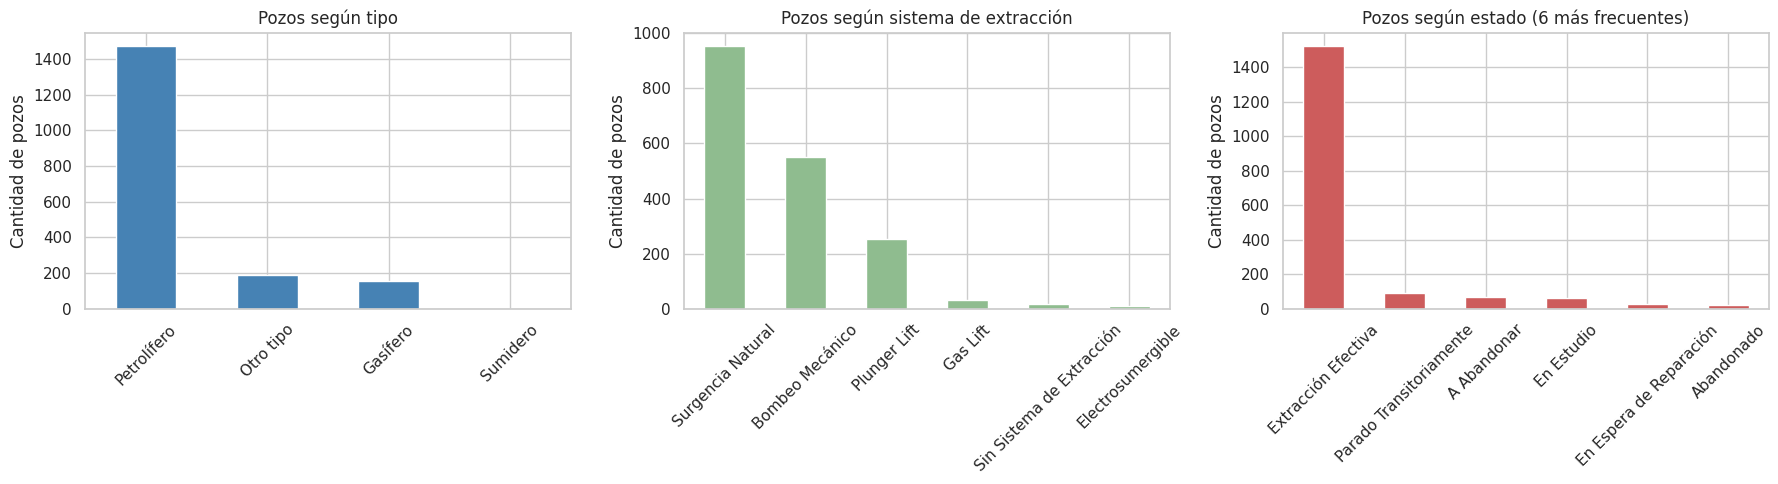

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

db_ypf["tipopozo"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pozos según tipo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad de pozos")
axes[0].tick_params(axis="x", rotation=45)

db_ypf["tipoextraccion"].value_counts().plot(kind="bar", ax=axes[1], color="darkseagreen")
axes[1].set_title("Pozos según sistema de extracción")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cantidad de pozos")
axes[1].tick_params(axis="x", rotation=45)

db_ypf["tipoestado"].value_counts().head(6).plot(kind="bar", ax=axes[2], color="indianred")
axes[2].set_title("Pozos según estado (6 más frecuentes)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cantidad de pozos")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [36]:
print("TIPO DE POZO")
print(db_ypf["tipopozo"].value_counts())
print("\nSISTEMA DE EXTRACCIÓN")
print(db_ypf["tipoextraccion"].value_counts())
print("\nESTADO")
print(db_ypf["tipoestado"].value_counts())

TIPO DE POZO
tipopozo
Petrolífero    1473
Otro tipo       188
Gasífero        155
Sumidero          2
Name: count, dtype: int64

SISTEMA DE EXTRACCIÓN
tipoextraccion
Surgencia Natural            953
Bombeo Mecánico              552
Plunger Lift                 254
Gas Lift                      32
Sin Sistema de Extracción     17
Electrosumergible             10
Name: count, dtype: int64

ESTADO
tipoestado
Extracción Efectiva        1523
Parado Transitoriamente      92
A Abandonar                  71
En Estudio                   63
En Espera de Reparación      26
Abandonado                   25
En Reserva de Gas             9
Abandono Temporario           4
Otras Situación Activo        2
En Inyección Efectiva         2
En Reparación                 1
Name: count, dtype: int64


In [37]:
# Clasificación y subclasificación: variables no exploradas en la primera versión del análisis
print("CLASIFICACIÓN")
print(db_ypf["clasificacion"].value_counts())
print("\nSUBCLASIFICACIÓN")
print(db_ypf["subclasificacion"].value_counts())

CLASIFICACIÓN
clasificacion
EXPLOTACION    1747
EXPLORACION      65
SERVICIO          6
Name: count, dtype: int64

SUBCLASIFICACIÓN
subclasificacion
DESARROLLO     1742
EXPLORACION      64
CONTROL           6
AVANZADA          5
EXTENSION         1
Name: count, dtype: int64


In [38]:
# Áreas
resumen_areas = (
    db_ypf.groupby("area")
    .agg(cantidad_pozos=("idpozo", "nunique"))
    .sort_values("cantidad_pozos", ascending=False)
)

print("Cantidad de áreas:", len(resumen_areas))
print("Total de pozos:   ", resumen_areas["cantidad_pozos"].sum())
resumen_areas

Cantidad de áreas: 28
Total de pozos:    1818


,cantidad_pozos
area,
LOMA CAMPANA,837
LA AMARGA CHICA,328
BANDURRIA SUR,219
EL OREJANO,95
LA ANGOSTURA SUR I,64
AGUADA DEL CHAÑAR,64
RINCON DEL MANGRULLO,58
AGUADA DE LA ARENA,41
BAJO DEL TORO NORTE,22


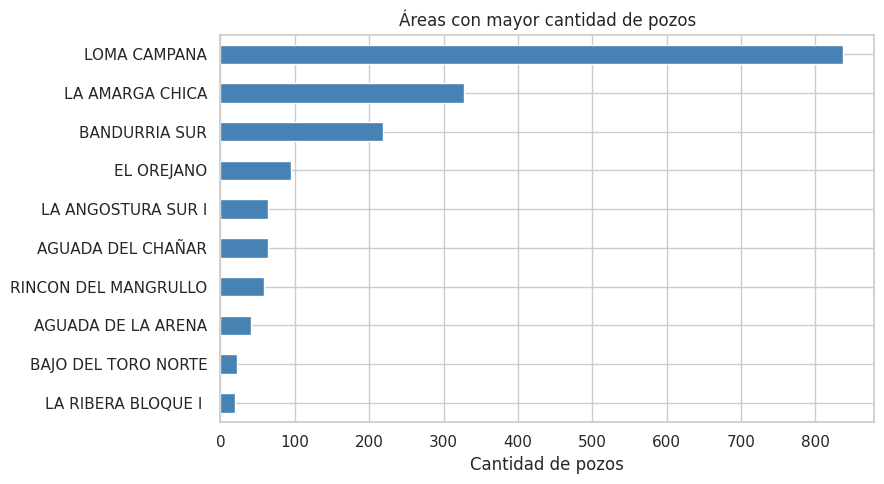

In [39]:
resumen_areas.head(10).plot(
    kind="barh", figsize=(9, 5), legend=False, color="steelblue"
)
plt.gca().invert_yaxis()
plt.title("Áreas con mayor cantidad de pozos")
plt.xlabel("Cantidad de pozos")
plt.ylabel("")
plt.tight_layout()
plt.show()

La distribución de pozos por área está fuertemente concentrada: unas pocas áreas concentran la mayor parte de los pozos,mientras que existe una cola de áreas con muy pocos pozos cada una. Esta concentración condiciona los análisis comparativos por área, que se restringirán a las áreas con cantidad suficiente de pozos.


### 11.1 Distribución de la profundidad

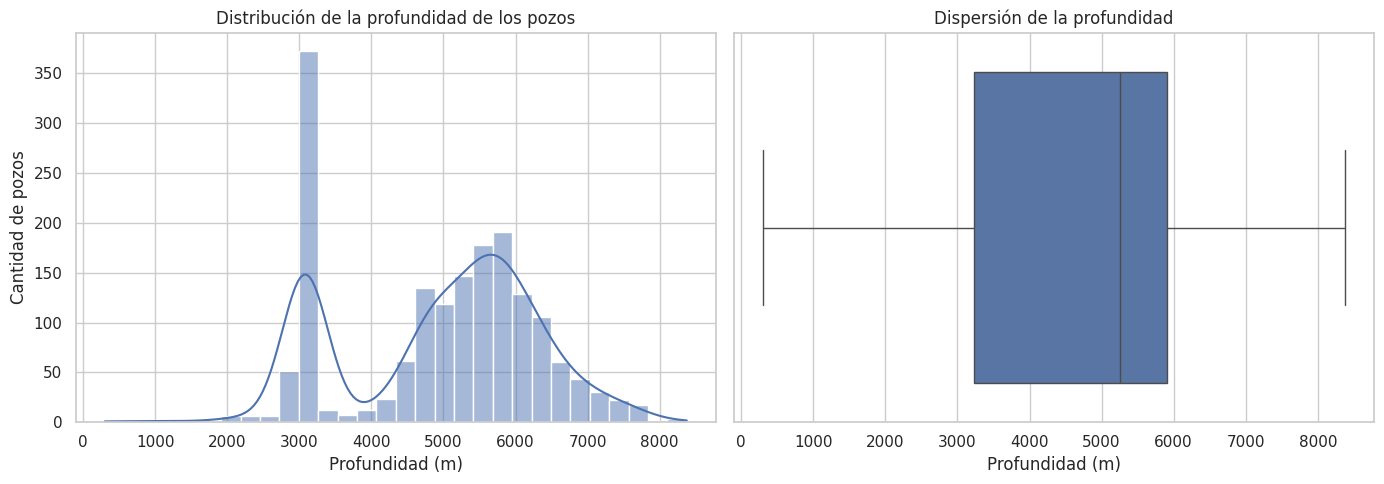

Asimetría de la profundidad: -0.312


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=db_ypf, x="profundidad_valida", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribución de la profundidad de los pozos")
axes[0].set_xlabel("Profundidad (m)")
axes[0].set_ylabel("Cantidad de pozos")

sns.boxplot(data=db_ypf, x="profundidad_valida", ax=axes[1])
axes[1].set_title("Dispersión de la profundidad")
axes[1].set_xlabel("Profundidad (m)")

plt.tight_layout()
plt.show()

print("Asimetría de la profundidad:", round(db_ypf["profundidad_valida"].skew(), 3))

La distribución de la profundidad no es unimodal: presenta dos concentraciones diferenciadas. Esto sugiere la coexistencia de **dos poblaciones de pozos** con geometrías distintas —típicamente pozos verticales y pozos horizontales, estos últimos con mayor profundidad medida total—.
Se verifica cruzando la profundidad con la clasificación del pozo.

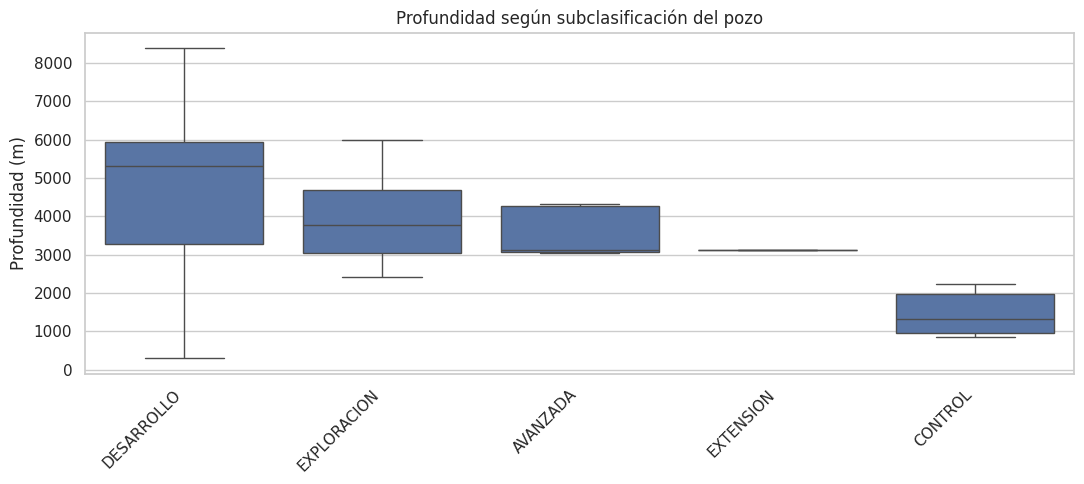

,count,mean,std,min,25%,50%,75%,max
subclasificacion,,,,,,,,
AVANZADA,5.0,3557.4,668.2,3040.0,3058.0,3112.0,4263.0,4314.0
CONTROL,6.0,1463.2,614.9,852.0,958.0,1327.5,1987.2,2230.0
DESARROLLO,1669.0,5010.0,1334.9,301.0,3275.0,5318.0,5942.0,8376.0
EXPLORACION,63.0,3908.3,941.5,2414.0,3047.0,3770.0,4697.0,5997.0
EXTENSION,1.0,3126.0,NaN,3126.0,3126.0,3126.0,3126.0,3126.0


In [41]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=db_ypf, x="subclasificacion", y="profundidad_valida")
plt.title("Profundidad según subclasificación del pozo")
plt.xlabel("")
plt.ylabel("Profundidad (m)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

db_ypf.groupby("subclasificacion")["profundidad_valida"].describe().round(1)

### 11.2 Duraciones operativas

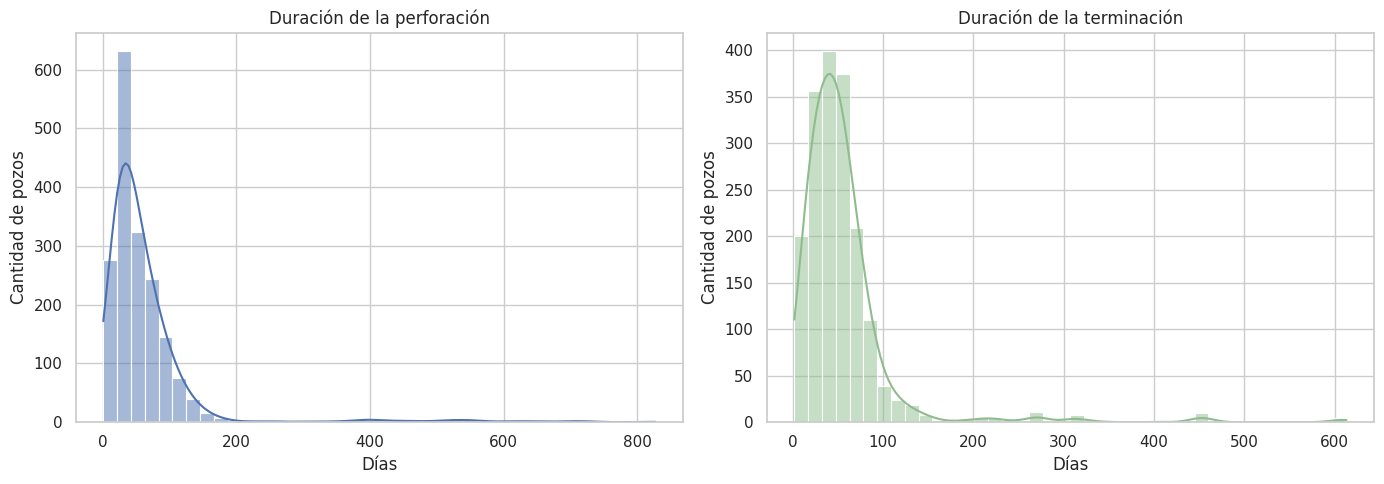

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=db_ypf, x="duracion_perforacion_valida", bins=40, kde=True, ax=axes[0])
axes[0].set_title("Duración de la perforación")
axes[0].set_xlabel("Días")
axes[0].set_ylabel("Cantidad de pozos")

sns.histplot(data=db_ypf, x="duracion_terminacion_valida", bins=40, kde=True,
             ax=axes[1], color="darkseagreen")
axes[1].set_title("Duración de la terminación")
axes[1].set_xlabel("Días")
axes[1].set_ylabel("Cantidad de pozos")

plt.tight_layout()
plt.show()

## 12. Análisis de las variables productivas

In [43]:
db_prod_vm[variables_produccion].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
prod_pet,141920.0,568.58,1151.65,0.0,2.45,58.50,562.33,13076.13
prod_gas,141920.0,324.06,1120.66,0.0,5.77,43.19,171.17,40086.80
prod_agua,141920.0,227.21,624.56,0.0,0.02,15.60,136.90,28671.30


In [44]:
# Diagnóstico de ceros, faltantes y asimetría
diagnostico = pd.DataFrame({
    "nulos": [db_prod_vm[v].isna().sum() for v in variables_produccion],
    "ceros": [(db_prod_vm[v] == 0).sum() for v in variables_produccion],
    "ceros_pct": [round((db_prod_vm[v] == 0).sum() / len(db_prod_vm) * 100, 2)
                  for v in variables_produccion],
    "negativos": [(db_prod_vm[v] < 0).sum() for v in variables_produccion],
    "asimetria": [round(db_prod_vm[v].skew(), 3) for v in variables_produccion],
}, index=variables_produccion)

diagnostico

,nulos,ceros,ceros_pct,negativos,asimetria
prod_pet,0,32728,23.06,0,3.345
prod_gas,0,27125,19.11,0,7.711
prod_agua,0,35349,24.91,0,6.487


In [45]:
# ¿Los ceros responden a meses sin actividad o a pozos que producen un solo hidrocarburo?
situacion = pd.Series({
    "Solo petróleo": ((db_prod_vm["prod_pet"] > 0) & (db_prod_vm["prod_gas"] == 0)).sum(),
    "Solo gas": ((db_prod_vm["prod_pet"] == 0) & (db_prod_vm["prod_gas"] > 0)).sum(),
    "Petróleo y gas": ((db_prod_vm["prod_pet"] > 0) & (db_prod_vm["prod_gas"] > 0)).sum(),
    "Sin petróleo ni gas": ((db_prod_vm["prod_pet"] == 0) & (db_prod_vm["prod_gas"] == 0)).sum(),
})

resultado = pd.DataFrame({
    "registros": situacion,
    "porcentaje": (situacion / situacion.sum() * 100).round(2),
})
resultado

,registros,porcentaje
Solo petróleo,403,0.28
Solo gas,6006,4.23
Petróleo y gas,108789,76.66
Sin petróleo ni gas,26722,18.83


In [46]:
# ¿Cuántos de los meses sin producción corresponden a meses sin actividad declarada?
sin_produccion = db_prod_vm[(db_prod_vm["prod_pet"] == 0) & (db_prod_vm["prod_gas"] == 0)]

print("Meses sin petróleo ni gas:", len(sin_produccion))
print("  de los cuales tienen tef = 0 (sin actividad):",
      (sin_produccion["tef"] == 0).sum())
print("  con tef > 0 pero producción nula:",
      (sin_produccion["tef"] > 0).sum())

Meses sin petróleo ni gas: 26722
  de los cuales tienen tef = 0 (sin actividad): 26632
  con tef > 0 pero producción nula: 90


La distinción es relevante: los meses con `tef = 0` corresponden a pozos **sin actividad** en el período y no deben interpretarse como baja productividad. Los meses con `tef > 0` y producción nula sí constituyen información productiva —el pozo operó y no produjo— y se conservan en el universo activo.

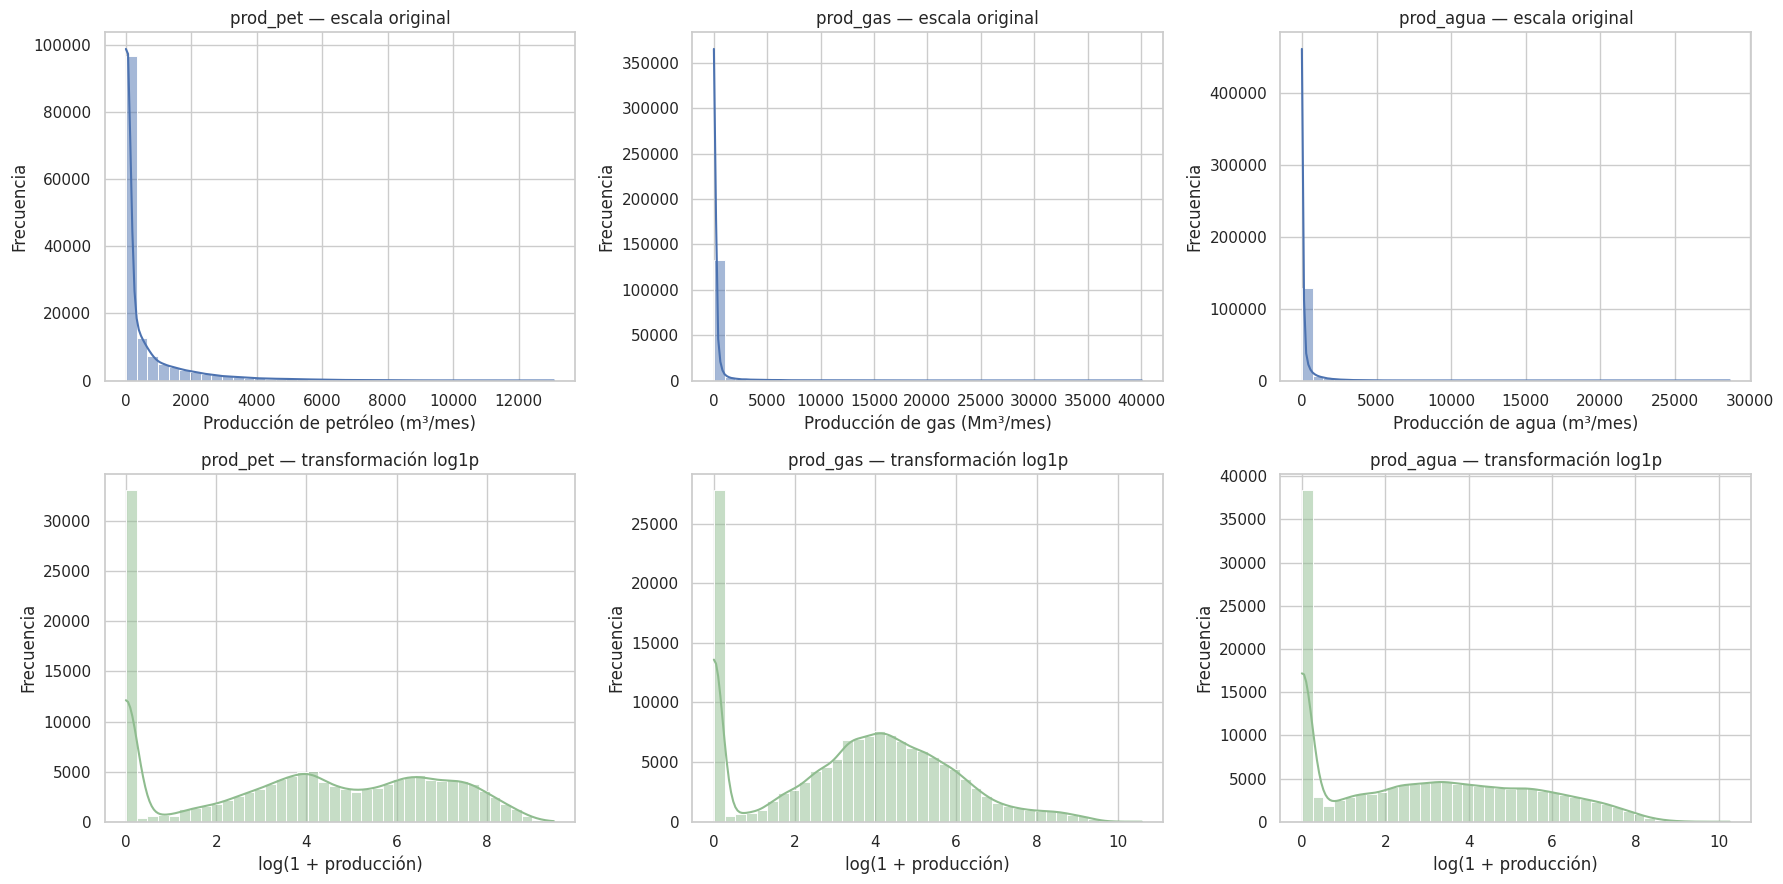

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for i, variable in enumerate(variables_produccion):
    sns.histplot(data=db_prod_vm, x=variable, bins=40, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"{variable} — escala original")
    axes[0, i].set_ylabel("Frecuencia")

    sns.histplot(data=db_prod_vm, x=variable + "_log", bins=40, kde=True,
                 ax=axes[1, i], color="darkseagreen")
    axes[1, i].set_title(f"{variable} — transformación log1p")
    axes[1, i].set_ylabel("Frecuencia")

axes[0, 0].set_xlabel("Producción de petróleo (m³/mes)")
axes[0, 1].set_xlabel("Producción de gas (Mm³/mes)")
axes[0, 2].set_xlabel("Producción de agua (m³/mes)")
for j in range(3):
    axes[1, j].set_xlabel("log(1 + producción)")

plt.tight_layout()
plt.show()

En la escala original las tres variables presentan distribuciones fuertemente asimétricas a la derecha. Tras la transformación logarítmica se observa la estructura **bimodal** anticipada: un pico en el origen, correspondiente a los meses sin producción, y una segunda moda que describe la distribución de los meses efectivamente productivos.

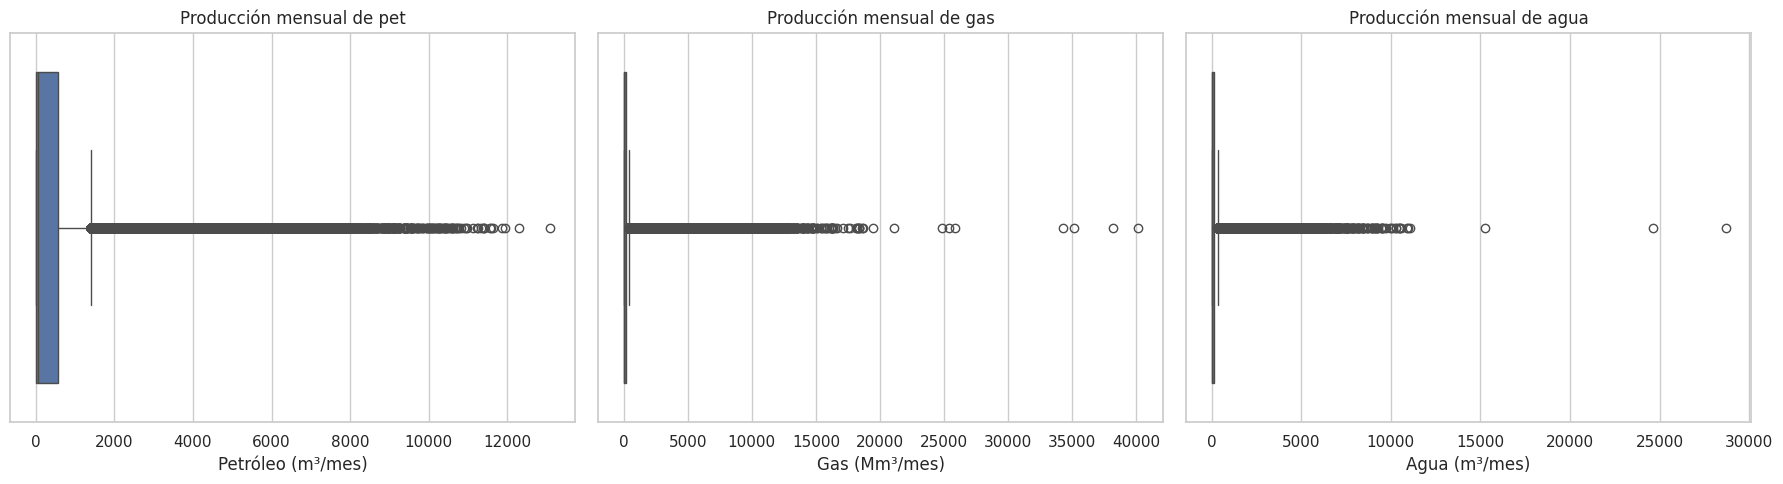

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
etiquetas = ["Petróleo (m³/mes)", "Gas (Mm³/mes)", "Agua (m³/mes)"]

for i, (variable, etiqueta) in enumerate(zip(variables_produccion, etiquetas)):
    sns.boxplot(data=db_prod_vm, x=variable, ax=axes[i])
    axes[i].set_title(f"Producción mensual de {variable.split('_')[1]}")
    axes[i].set_xlabel(etiqueta)

plt.tight_layout()
plt.show()

### 12.1 Sobre la detección de valores atípicos
Los boxplots muestran numerosos registros alejados del rango central. Se evalúa el criterio del rango intercuartílico (IQR) para dimensionar el fenómeno, teniendo presente una limitación importante: **el criterio IQR supone distribuciones aproximadamente simétricas**. Aplicado a variables con asimetría elevada y una masa relevante de ceros, tiende a clasificar como atípica una porción sustancial de los datos, lo que constituye un artefacto del método y no evidencia de error en los registros.

In [49]:
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return pd.Series({
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "limite_superior": round(limite_superior, 2),
        "registros_atipicos": len(outliers),
        "pct_del_total": round(len(outliers) / len(df) * 100, 2),
        "pozos_involucrados": outliers["idpozo"].nunique(),
    })

pd.DataFrame({v: detectar_outliers_iqr(db_prod_vm, v) for v in variables_produccion})

,prod_pet,prod_gas,prod_agua
Q1,2.45,5.77,0.02
Q3,562.33,171.17,136.90
IQR,559.88,165.40,136.88
limite_superior,1402.14,419.26,342.23
registros_atipicos,18957.00,18254.00,21951.00
pct_del_total,13.36,12.86,15.47
pozos_involucrados,1197.00,1368.00,1774.00


El criterio marca como atípica una fracción muy elevada de los registros, involucrando a la mayoría de los pozos. **No se eliminan observaciones sobre esta base.** En su lugar se aplica un criterio de plausibilidad física sobre el caudal diario, que sí permite identificar registros potencialmente erróneos.

In [50]:
# Criterio de plausibilidad: caudales diarios extremos dentro del universo activo
umbral_pet = db_activos["caudal_pet"].quantile(0.999)
umbral_gas = db_activos["caudal_gas"].quantile(0.999)

print(f"Percentil 99,9 del caudal de petróleo: {umbral_pet:.2f} m³/día")
print(f"Percentil 99,9 del caudal de gas:      {umbral_gas:.2f} Mm³/día")
print()

sospechosos = db_activos[
    (db_activos["caudal_pet"] > umbral_pet) | (db_activos["caudal_gas"] > umbral_gas)
]

print("Registros por encima del percentil 99,9:", len(sospechosos))
print("Pozos involucrados:", sospechosos["idpozo"].nunique())

sospechosos[["idpozo", "fecha", "tef", "prod_pet", "caudal_pet",
             "prod_gas", "caudal_gas"]].sort_values("caudal_pet", ascending=False).head(10)

Percentil 99,9 del caudal de petróleo: 304.76 m³/día
Percentil 99,9 del caudal de gas:      444.38 Mm³/día

Registros por encima del percentil 99,9: 232
Pozos involucrados: 109


,idpozo,fecha,tef,prod_pet,caudal_pet,prod_gas,caudal_gas
58920,154555,2016-09-01,0.01,23.89,2389.000000,0.00,0.000000
138504,166250,2025-11-01,0.02,23.55,1177.500000,4.09,204.500000
136984,165714,2026-07-01,0.13,85.60,658.461538,0.60,4.615385
77355,156552,2019-12-01,0.04,18.60,465.000000,0.00,0.000000
140735,166825,2026-01-01,30.83,13076.13,424.136555,5165.01,167.531949
140524,166808,2025-12-01,30.94,12288.66,397.177117,1586.52,51.277311
140608,166815,2025-11-01,29.90,11645.30,389.474916,1304.63,43.633110
110252,162024,2021-04-01,29.98,11550.42,385.270847,1027.55,34.274516
139102,166451,2025-07-01,31.00,11942.74,385.249677,1075.68,34.699355
141177,166932,2026-01-01,30.88,11865.34,384.240285,1492.48,48.331606


Estos registros se revisan individualmente antes de decidir cualquier tratamiento. Valores elevados de caudal son esperables en los primeros meses de un pozo no convencional, por lo que la decisión de conservarlos o corregirlos debe apoyarse en el contexto del pozo —en particular, en su antigüedad al momento del registro— y no únicamente en la magnitud del valor.

## 13. Variables operativas dinámicas
Antes de comparar la producción entre grupos es necesario determinar si los atributos usados para agrupar son **fijos** por pozo o **cambian a lo largo del tiempo**. Esta verificación condiciona la forma correcta de agrupar y la interpretación de los resultados.

In [51]:
tipos_por_pozo = db_prod_vm.groupby("idpozo")["tipopozo"].nunique()
extraccion_por_pozo = db_prod_vm.groupby("idpozo")["tipoextraccion"].nunique()

resumen_dinamicas = pd.DataFrame({
    "un_solo_valor": [(tipos_por_pozo == 1).sum(), (extraccion_por_pozo == 1).sum()],
    "mas_de_un_valor": [(tipos_por_pozo > 1).sum(), (extraccion_por_pozo > 1).sum()],
}, index=["tipopozo", "tipoextraccion"])

resumen_dinamicas["pct_cambia"] = (
    resumen_dinamicas["mas_de_un_valor"] /
    (resumen_dinamicas["un_solo_valor"] + resumen_dinamicas["mas_de_un_valor"]) * 100
).round(2)

resumen_dinamicas

,un_solo_valor,mas_de_un_valor,pct_cambia
tipopozo,1391,427,23.49
tipoextraccion,733,1085,59.68


In [52]:
# Combinaciones de tipos observadas en pozos que cambian de clasificación
combinaciones = (
    db_prod_vm.groupby("idpozo")["tipopozo"]
    .apply(lambda x: tuple(sorted(x.dropna().unique())))
)

combinaciones[combinaciones.apply(len) > 1].value_counts()

,count
tipopozo,
"(Otro tipo, Petrolífero)",315
"(Gasífero, Otro tipo)",96
"(Gasífero, Otro tipo, Petrolífero)",14
"(Gasífero, Petrolífero)",1
"(Otro tipo, Sumidero)",1


**Consecuencia metodológica.** Una proporción relevante de los pozos cambia de tipo y/o de sistema de extracción a lo largo de su historia. Por lo tanto:
- Los análisis comparativos por `tipopozo` y `tipoextraccion` se realizan **a nivel de registro mensual**, no a nivel de  pozo: cada mes se clasifica según el atributo vigente en ese período.
- Los resultados describen **asociaciones entre la configuración operativa vigente y la producción observada**, y no  relaciones causales: el sistema de extracción suele modificarse *como respuesta* a la evolución productiva del pozo,  de modo que la dirección de la relación no puede establecerse con este análisis.
- Existe además una diferencia entre la clasificación registrada en el dataset técnico (situación actual del pozo) y la  registrada mes a mes en el dataset de producción. Se utiliza esta última en los análisis productivos, por ser la  contemporánea a cada registro.

In [53]:
# Comparación entre ambas fuentes de clasificación
clasif_tecnica = db_ypf["tipopozo"].value_counts().rename("dataset_tecnico_actual")
clasif_produccion = (
    db_prod_vm.groupby("tipopozo")["idpozo"].nunique().rename("pozos_con_algun_registro")
)

pd.concat([clasif_tecnica, clasif_produccion], axis=1)

,dataset_tecnico_actual,pozos_con_algun_registro
tipopozo,,
Petrolífero,1473,1587
Otro tipo,188,437
Gasífero,155,233
Sumidero,2,2


## 14. Contexto: diferencias productivas entre grupos de pozos
Antes de enfocarse en la pregunta central conviene tener un panorama general de cómo varía la producción mensual entre grupos de pozos. Todas las comparaciones se presentan sobre el **universo de meses activos** (`tef > 0`) y se reportan media y mediana conjuntamente, dado que la fuerte asimetría hace que ambas medidas describan aspectos distintos de la distribución.

### 14.1 Por tipo de pozo

In [54]:
def comparar_grupos(df, variable_grupo, variables=("prod_pet", "prod_gas", "prod_agua")):
    variables = list(variables)
    resumen = df.groupby(variable_grupo).agg(
        registros=("idpozo", "size"),
        pozos=("idpozo", "nunique"),
    )
    medias = df.groupby(variable_grupo)[variables].mean().round(2).add_suffix("_media")
    medianas = df.groupby(variable_grupo)[variables].median().round(2).add_suffix("_mediana")
    return pd.concat([resumen, medianas, medias], axis=1).sort_values("registros", ascending=False)


comparacion_tipo = comparar_grupos(db_activos, "tipopozo")
comparacion_tipo

,registros,pozos,prod_pet_mediana,prod_gas_mediana,prod_agua_mediana,prod_pet_media,prod_gas_media,prod_agua_media
tipopozo,,,,,,,,
Petrolífero,104348,1581,187.05,59.29,28.80,767.77,150.73,263.55
Gasífero,10878,231,0.00,1771.83,185.46,51.74,2781.22,435.22
Sumidero,43,1,0.00,0.00,0.00,0.00,0.00,0.00
Otro tipo,14,5,1203.72,490.57,512.14,1032.63,571.09,739.65


In [55]:
# Contraste con el cálculo sin filtrar meses inactivos
sin_filtro = db_prod_vm.groupby("tipopozo")[variables_produccion].median().round(2)
con_filtro = db_activos.groupby("tipopozo")[variables_produccion].median().round(2)

comparacion_criterios = pd.concat(
    [sin_filtro.add_suffix("_todos_los_meses"), con_filtro.add_suffix("_meses_activos")],
    axis=1,
)
comparacion_criterios

,prod_pet_todos_los_meses,prod_gas_todos_los_meses,prod_agua_todos_los_meses,prod_pet_meses_activos,prod_gas_meses_activos,prod_agua_meses_activos
tipopozo,,,,,,
Gasífero,0.00,1229.10,114.66,0.00,1771.83,185.46
Otro tipo,0.00,0.00,0.00,1203.72,490.57,512.14
Petrolífero,127.58,50.03,21.76,187.05,59.29,28.80
Sumidero,0.00,0.00,0.00,0.00,0.00,0.00


La comparación entre ambos criterios muestra por qué la distinción importa: al incluir los meses sin actividad, lasmedianas se desplazan hacia cero y describen la **proporción de meses inactivos** de cada grupo antes que su capacidadproductiva. El análisis se apoya en el universo activo; el cálculo sin filtrar se conserva únicamente como contrastemetodológico.

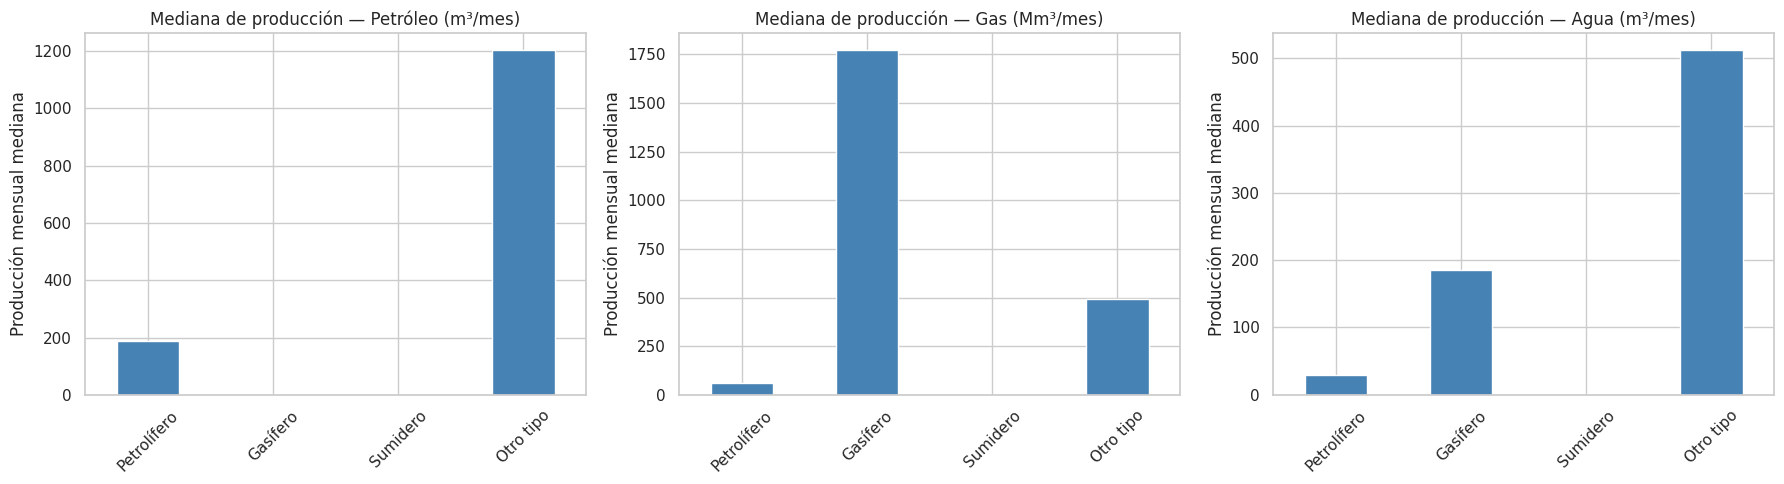

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
columnas = ["prod_pet_mediana", "prod_gas_mediana", "prod_agua_mediana"]
titulos = ["Petróleo (m³/mes)", "Gas (Mm³/mes)", "Agua (m³/mes)"]

for ax, columna, titulo in zip(axes, columnas, titulos):
    comparacion_tipo[columna].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Mediana de producción — {titulo}")
    ax.set_xlabel("")
    ax.set_ylabel("Producción mensual mediana")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 14.2 Por sistema de extracción

In [57]:
comparacion_extraccion = comparar_grupos(db_activos, "tipoextraccion")
comparacion_extraccion

,registros,pozos,prod_pet_mediana,prod_gas_mediana,prod_agua_mediana,prod_pet_media,prod_gas_media,prod_agua_media
tipoextraccion,,,,,,,,
Surgencia Natural,52715,1803,744.99,240.67,204.42,1301.62,802.38,551.38
Plunger Lift,35937,409,31.55,27.43,8.76,57.03,44.84,25.89
Bombeo Mecánico,24936,707,271.66,47.27,19.76,359.68,66.67,79.95
Gas Lift,1287,40,295.88,148.01,41.80,516.51,266.36,145.49
Bombeo Hidráulico,221,9,369.47,51.96,8.64,412.49,77.11,40.01
Electrosumergible,132,14,2087.19,393.96,212.02,2291.42,446.88,447.60
Sin Sistema de Extracción,43,1,0.00,0.00,0.00,0.00,0.00,0.00
Jet Pump,8,1,143.36,0.00,6.89,106.68,5.13,6.33
Pistoneo (Swabbing),4,1,0.50,0.00,1.66,0.48,0.00,1.42


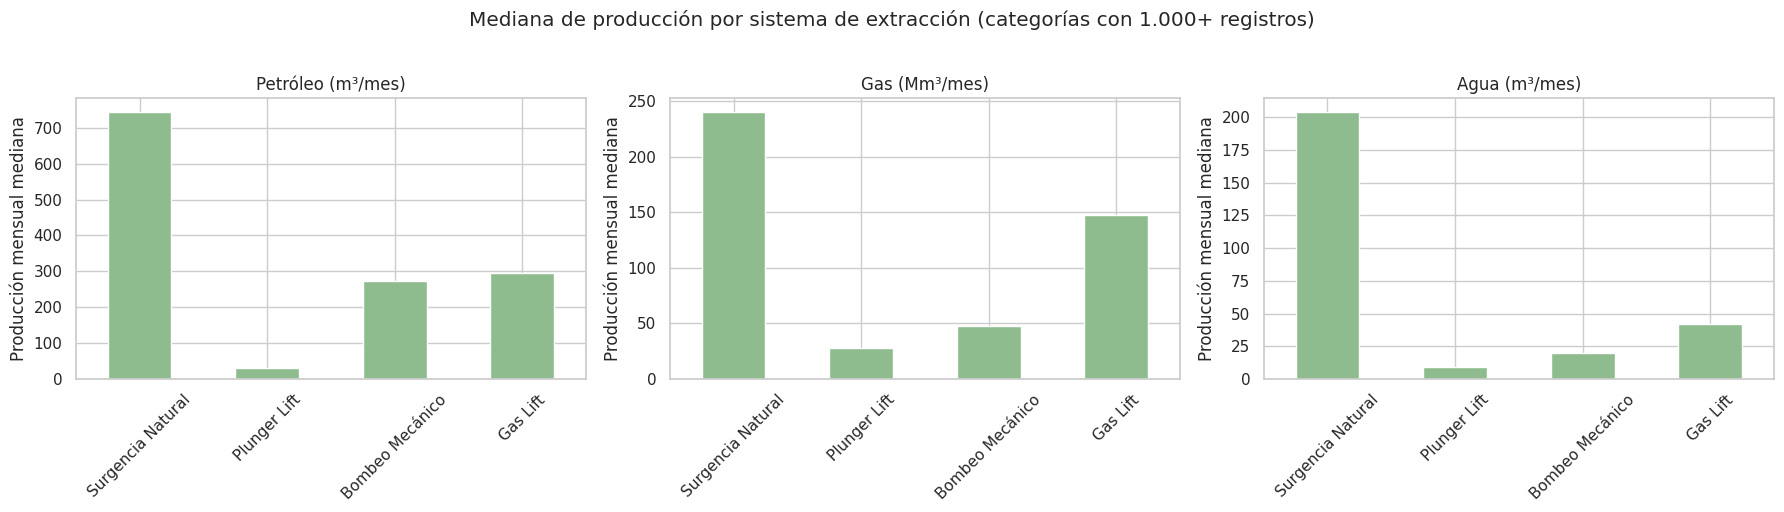

In [58]:
# Se grafican únicamente las categorías con representatividad suficiente
extracciones_representativas = comparacion_extraccion[
    comparacion_extraccion["registros"] >= 1000
].index

grafico_extraccion = comparacion_extraccion.loc[extracciones_representativas]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, columna, titulo in zip(axes, columnas, titulos):
    grafico_extraccion[columna].plot(kind="bar", ax=ax, color="darkseagreen")
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Producción mensual mediana")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Mediana de producción por sistema de extracción (categorías con 1.000+ registros)",
             y=1.02)
plt.tight_layout()
plt.show()

### 14.3 Por área
El área es un atributo del pozo y proviene del dataset técnico, por lo que se incorpora al dataset de producción mediante un `merge` por `idpozo`.

In [59]:
pozos_area = db_ypf[["idpozo", "area", "profundidad_valida", "subclasificacion"]].copy()

db_activos = db_activos.merge(pozos_area, on="idpozo", how="left", suffixes=("", "_tecnico"))

print("Registros antes del merge:", len(db_activos))
print("Pozos únicos:             ", db_activos["idpozo"].nunique())
print("Registros sin área asignada:", db_activos["area"].isna().sum())

Registros antes del merge: 115283
Pozos únicos:              1805
Registros sin área asignada: 0


Se utiliza un `merge` de tipo **left** porque la tabla principal del análisis es la de registros mensuales: se busca enriquecerla con los atributos del pozo sin alterar su cantidad de filas. La verificación posterior confirma que la cantidad de registros no cambió y que no quedaron valores sin asignar, lo que descarta duplicaciones por claves repetidas.

In [60]:
areas_representativas = resumen_areas[resumen_areas["cantidad_pozos"] >= 50].index
print("Áreas incluidas en la comparación:", list(areas_representativas))

db_areas = db_activos[db_activos["area"].isin(areas_representativas)].copy()

print("\nRegistros incluidos:", len(db_areas))
print("Pozos incluidos:    ", db_areas["idpozo"].nunique())
print("Cobertura sobre el universo activo:",
      round(len(db_areas) / len(db_activos) * 100, 2), "%")

Áreas incluidas en la comparación: ['LOMA CAMPANA', 'LA AMARGA CHICA', 'BANDURRIA SUR', 'EL OREJANO', 'LA ANGOSTURA SUR I', 'AGUADA DEL CHAÑAR', 'RINCON DEL MANGRULLO']

Registros incluidos: 109424
Pozos incluidos:     1655
Cobertura sobre el universo activo: 94.92 %


In [61]:
comparacion_area = comparar_grupos(db_areas, "area")
comparacion_area

,registros,pozos,prod_pet_mediana,prod_gas_mediana,prod_agua_mediana,prod_pet_media,prod_gas_media,prod_agua_media
area,,,,,,,,
LOMA CAMPANA,77742,832,76.90,42.66,15.24,470.95,114.16,116.92
LA AMARGA CHICA,14220,328,989.78,116.94,211.98,1480.89,179.40,591.40
BANDURRIA SUR,7532,219,1482.62,265.68,380.46,1886.93,351.71,825.11
EL OREJANO,5025,90,0.00,1275.86,146.29,7.46,2044.53,345.86
RINCON DEL MANGRULLO,2437,58,6.67,3533.33,278.21,19.85,4309.18,554.41
AGUADA DEL CHAÑAR,1469,64,1573.32,114.14,676.50,1873.73,143.05,986.56
LA ANGOSTURA SUR I,999,64,2586.71,579.64,344.47,2999.16,684.81,949.26


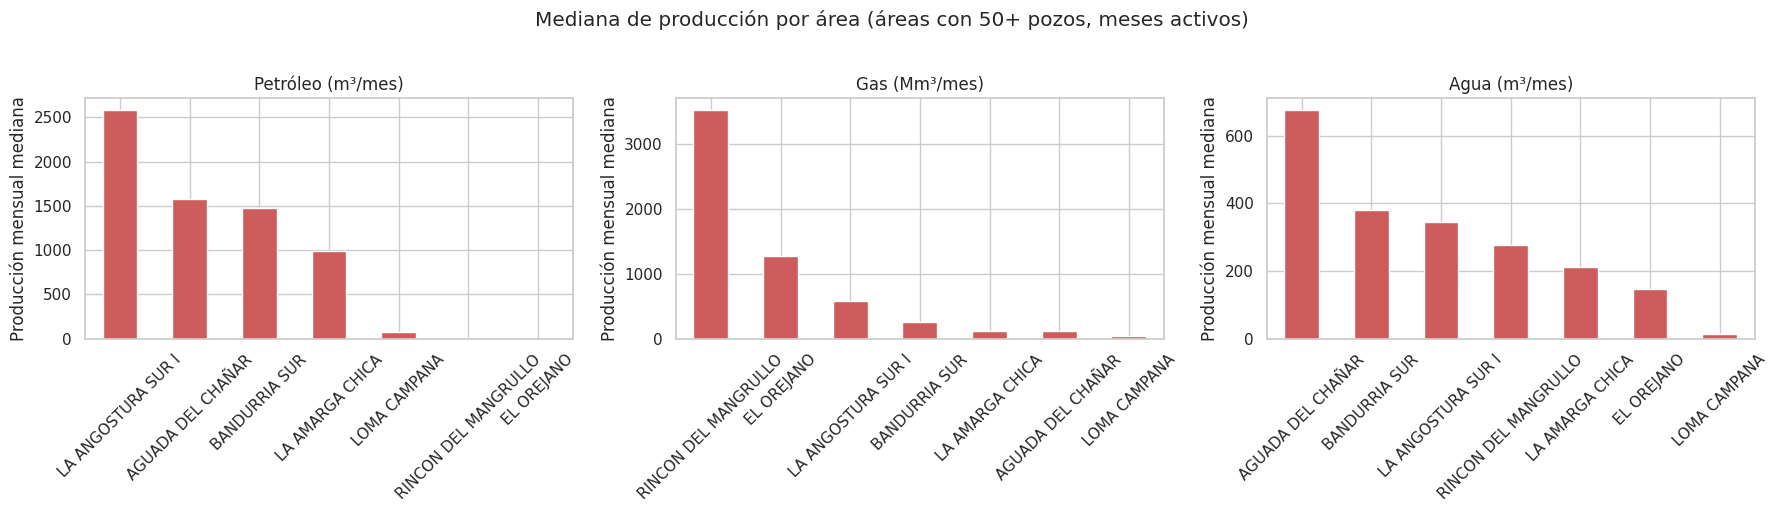

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, columna, titulo in zip(axes, columnas, titulos):
    comparacion_area[columna].sort_values(ascending=False).plot(
        kind="bar", ax=ax, color="indianred"
    )
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Producción mensual mediana")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Mediana de producción por área (áreas con 50+ pozos, meses activos)", y=1.02)
plt.tight_layout()
plt.show()

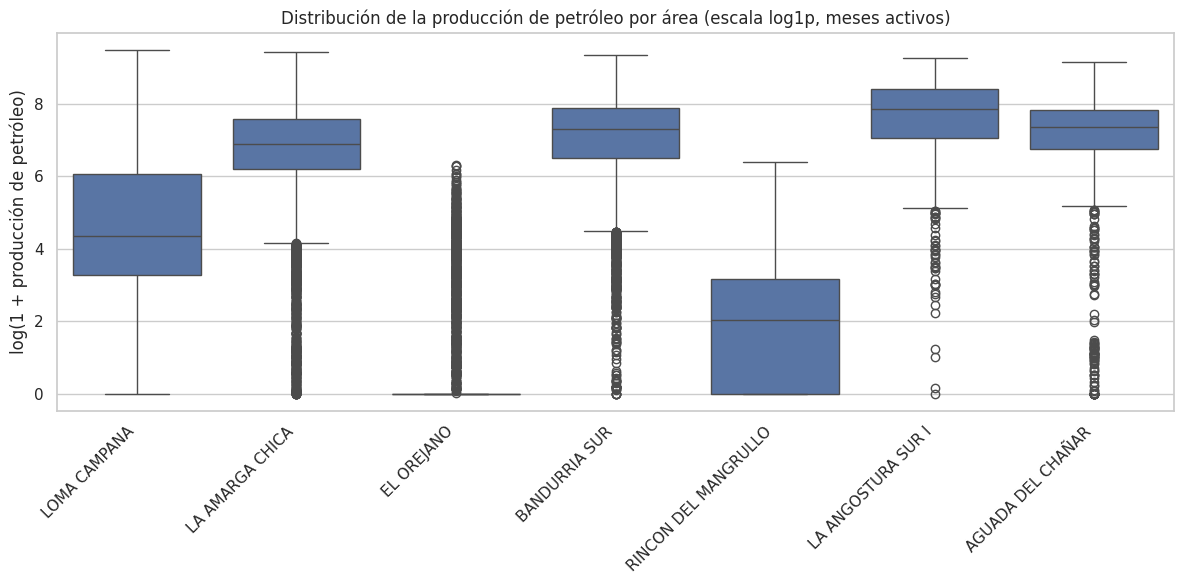

In [63]:
# Dispersión dentro de cada área, no solo la medida central
plt.figure(figsize=(12, 6))
sns.boxplot(data=db_areas, x="area", y="prod_pet_log")
plt.title("Distribución de la producción de petróleo por área (escala log1p, meses activos)")
plt.xlabel("")
plt.ylabel("log(1 + producción de petróleo)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

El boxplot en escala logarítmica permite comparar las áreas considerando la **dispersión** y no únicamente la mediana. Áreas con medianas similares pueden presentar perfiles de variabilidad muy distintos, lo que resulta relevante para evaluar el riesgo asociado a cada una y para una eventual etapa de modelado.

## 15. Análisis temporal
Responde a la pregunta 2. Se aborda desde dos perspectivas complementarias: la evolución agregada del conjunto de pozos a lo largo del tiempo calendario, y el comportamiento típico de un pozo individual a lo largo de su propia vida útil.

### 15.1 Evolución agregada de la producción (contexto)

In [64]:
serie_mensual = db_prod_vm.groupby("fecha").agg(
    pet_total=("prod_pet", "sum"),
    gas_total=("prod_gas", "sum"),
    agua_total=("prod_agua", "sum"),
    pozos_activos=("idpozo", "nunique"),
)

serie_mensual.tail(12)

,pet_total,gas_total,agua_total,pozos_activos
fecha,,,,
2025-09-01,1387430.13,552151.68,727242.82,1669
2025-10-01,1495180.89,486895.09,696578.85,1692
2025-11-01,1498450.29,469180.16,639564.13,1706
2025-12-01,1617379.72,517398.30,662089.11,1728
2026-01-01,1628409.67,505202.60,678515.82,1733
2026-02-01,1404544.20,521976.76,585319.44,1758
2026-03-01,1576708.60,645004.66,692359.70,1773
2026-04-01,1561485.94,567376.15,706776.03,1791
2026-05-01,1571587.08,710969.73,718910.70,1818


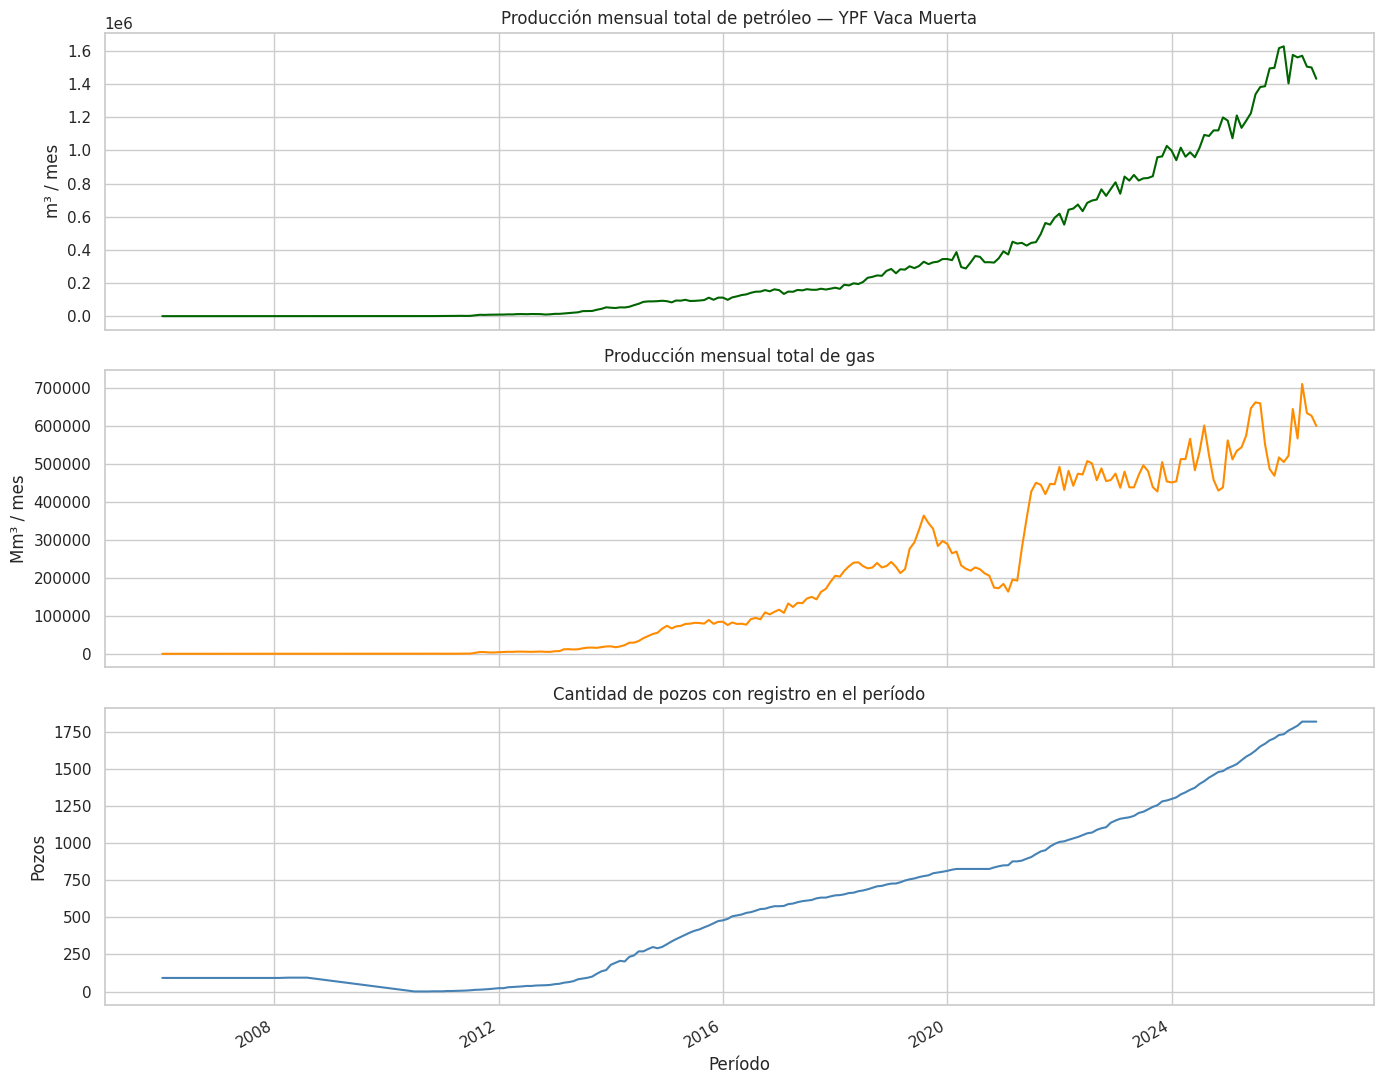

In [65]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

serie_mensual["pet_total"].plot(ax=axes[0], color="darkgreen")
axes[0].set_title("Producción mensual total de petróleo — YPF Vaca Muerta")
axes[0].set_ylabel("m³ / mes")

serie_mensual["gas_total"].plot(ax=axes[1], color="darkorange")
axes[1].set_title("Producción mensual total de gas")
axes[1].set_ylabel("Mm³ / mes")

serie_mensual["pozos_activos"].plot(ax=axes[2], color="steelblue")
axes[2].set_title("Cantidad de pozos con registro en el período")
axes[2].set_ylabel("Pozos")
axes[2].set_xlabel("Período")

plt.tight_layout()
plt.show()

La comparación entre la producción total y la cantidad de pozos permite distinguir si el crecimiento agregado responde a la **incorporación de nuevos pozos** o a una mejora en la productividad por pozo. Los últimos períodos deben leerse con cautela por la posible carga parcial de la fuente.

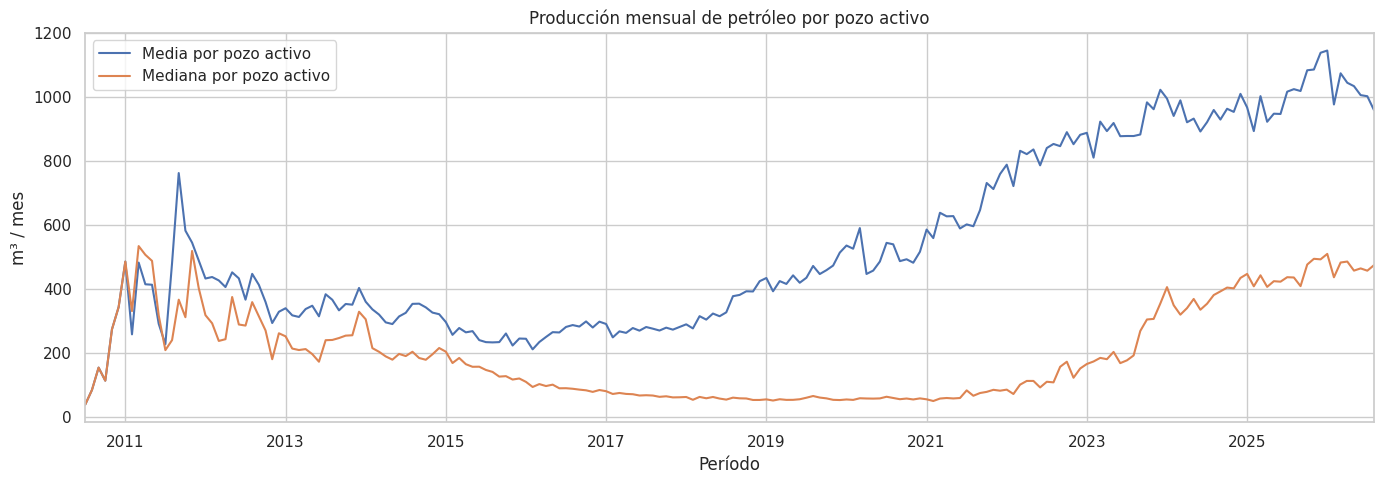

In [66]:
# Producción media por pozo activo: aísla el efecto de la incorporación de pozos
serie_activos = db_activos.groupby("fecha").agg(
    pet_mediana=("prod_pet", "median"),
    pet_media=("prod_pet", "mean"),
    pozos=("idpozo", "nunique"),
)

fig, ax = plt.subplots(figsize=(14, 5))
serie_activos["pet_media"].plot(ax=ax, label="Media por pozo activo")
serie_activos["pet_mediana"].plot(ax=ax, label="Mediana por pozo activo")
ax.set_title("Producción mensual de petróleo por pozo activo")
ax.set_ylabel("m³ / mes")
ax.set_xlabel("Período")
ax.legend()
plt.tight_layout()
plt.show()

### 15.2 Pozos con al menos 24 meses de historia
Para responder la pregunta central es necesario restringir el análisis a los pozos que ya cumplieron 24 meses de operación: los pozos perforados más recientemente todavía no acumularon ese tiempo, y si se los incluyera su volumen acumulado aparecería artificialmente bajo, no porque produzcan poco sino porque les falta historia.

In [67]:
# Meses de historia disponibles por pozo (dentro del universo de meses activos)
historia = db_activos.groupby("idpozo")["mes_produccion"].max()

pozos_con_24m = historia[historia >= 24].index

print("Pozos con registros de producción:        ", len(historia))
print("Pozos con 24 meses o más de historia:      ", len(pozos_con_24m))
print("Pozos excluidos por historia insuficiente: ", len(historia) - len(pozos_con_24m))

Pozos con registros de producción:         1805
Pozos con 24 meses o más de historia:       1404
Pozos excluidos por historia insuficiente:  401


## 16. Producción de los primeros 24 meses
Ésta es la pregunta central del trabajo: **¿cuánto produce un pozo de YPF en Vaca Muerta durante sus primeros 24 meses de operación, y qué tan distinto es ese volumen entre pozos?** Se calcula, para cada pozo con historia suficiente, el petróleo acumulado en sus primeros 24 meses de producción.

In [68]:
prod_24m = (
    db_activos[
        db_activos["idpozo"].isin(pozos_con_24m) &
        (db_activos["mes_produccion"] <= 24)
    ]
    .groupby("idpozo")
    .agg(
        pet_24m=("prod_pet", "sum"),
        gas_24m=("prod_gas", "sum"),
        pico_pet=("prod_pet", "max"),
        mes_del_pico=("prod_pet", "idxmax"),
    )
)

print("Pozos incluidos en el análisis:", len(prod_24m))
prod_24m["pet_24m"].describe().round(0)

Pozos incluidos en el análisis: 1313


,pet_24m
count,1313.0
mean,33311.0
std,29273.0
min,0.0
25%,4810.0
50%,29639.0
75%,56772.0
max,144063.0


### 16.1 ¿Cuánto produce un pozo típico?

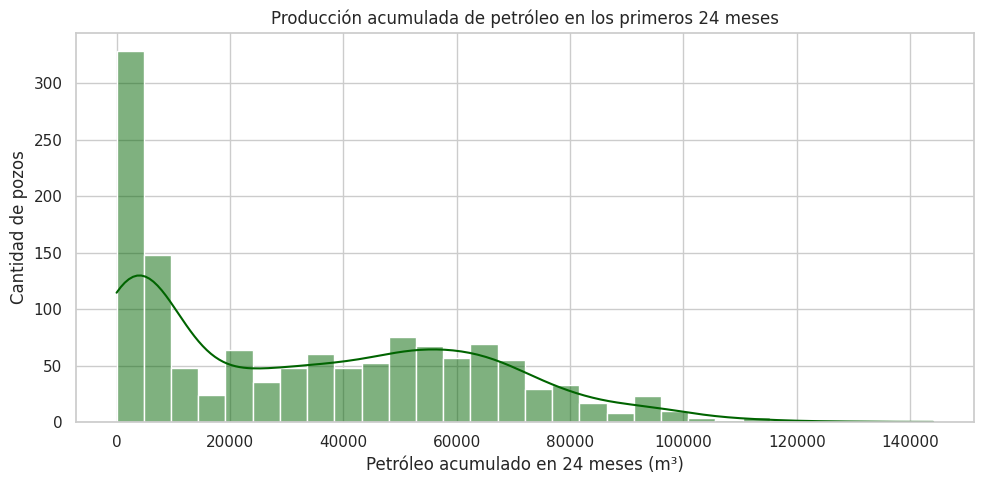

Mediana: 29639.0 m³
Media:   33311.0 m³


In [69]:
plt.figure(figsize=(10, 5))
sns.histplot(data=prod_24m, x="pet_24m", bins=30, kde=True, color="darkgreen")
plt.title("Producción acumulada de petróleo en los primeros 24 meses")
plt.xlabel("Petróleo acumulado en 24 meses (m³)")
plt.ylabel("Cantidad de pozos")
plt.tight_layout()
plt.show()

print("Mediana:", round(prod_24m["pet_24m"].median(), 0), "m³")
print("Media:  ", round(prod_24m["pet_24m"].mean(), 0), "m³")

La diferencia entre la media y la mediana ya anticipa la respuesta a la segunda parte de la pregunta: si ambas fueran similares, los pozos producirían montos parecidos entre sí. Que difieran indica que unos pocos pozos muy productivos empujan la media hacia arriba, mientras que la mayoría produce menos que ese promedio.

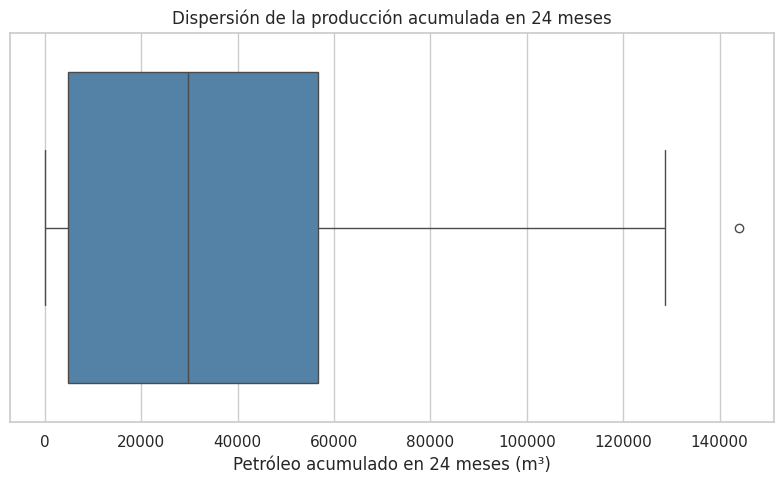

In [70]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=prod_24m["pet_24m"], color="steelblue")
plt.title("Dispersión de la producción acumulada en 24 meses")
plt.xlabel("Petróleo acumulado en 24 meses (m³)")
plt.tight_layout()
plt.show()

### 16.2 ¿En qué parte de esos 24 meses se concentra la producción?
Se construye la curva de declinación acotada a los 24 meses, alineando a todos los pozos por su antigüedad (mes deproducción desde el inicio) en lugar de por fecha calendario, de modo que el patrón pueda observarse con independencia del año en que cada pozo arrancó.

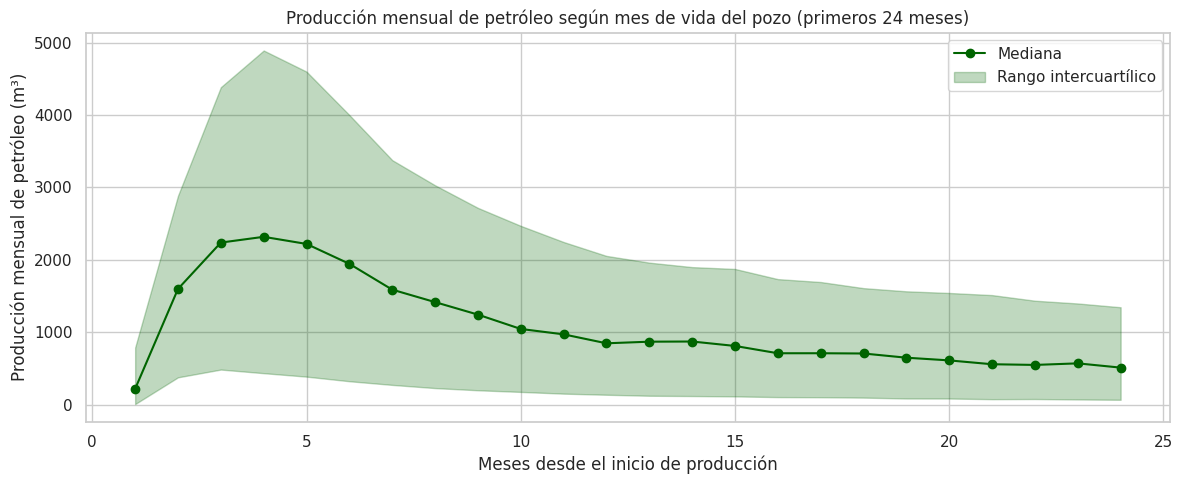

In [71]:
curva_24m = (
    db_activos[
        db_activos["idpozo"].isin(pozos_con_24m) &
        (db_activos["mes_produccion"] <= 24)
    ]
    .groupby("mes_produccion")
    .agg(
        pet_mediana=("prod_pet", "median"),
        pet_p25=("prod_pet", lambda x: x.quantile(0.25)),
        pet_p75=("prod_pet", lambda x: x.quantile(0.75)),
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curva_24m.index, curva_24m["pet_mediana"], marker="o", color="darkgreen",
        label="Mediana")
ax.fill_between(curva_24m.index, curva_24m["pet_p25"], curva_24m["pet_p75"],
                alpha=0.25, color="darkgreen", label="Rango intercuartílico")
ax.set_title("Producción mensual de petróleo según mes de vida del pozo (primeros 24 meses)")
ax.set_xlabel("Meses desde el inicio de producción")
ax.set_ylabel("Producción mensual de petróleo (m³)")
ax.legend()
plt.tight_layout()
plt.show()

In [72]:
# Porcentaje del acumulado de 24 meses que se produce en los primeros 6
primeros_6m = (
    db_activos[
        db_activos["idpozo"].isin(pozos_con_24m) &
        (db_activos["mes_produccion"] <= 6)
    ]
    .groupby("idpozo")["prod_pet"].sum()
)

comparacion_6_24 = pd.DataFrame({
    "pet_6m": primeros_6m,
    "pet_24m": prod_24m["pet_24m"],
})
comparacion_6_24["pct_en_primeros_6m"] = (
    comparacion_6_24["pet_6m"] / comparacion_6_24["pet_24m"] * 100
)

print("Porcentaje del acumulado de 24 meses producido en los primeros 6 (mediana):",
      round(comparacion_6_24["pct_en_primeros_6m"].median(), 1), "%")

Porcentaje del acumulado de 24 meses producido en los primeros 6 (mediana): 38.7 %


Esa cifra resume el patrón: gran parte de lo que un pozo va a producir en sus primeros dos años ya se produjo en el primer semestre. El resto de los 24 meses aporta cada vez menos.

### 16.3 ¿Cambia según el área?
Se incorpora el área de cada pozo, proveniente del dataset técnico, y se compara la producción de 24 meses entre las áreas con mayor cantidad de pozos.

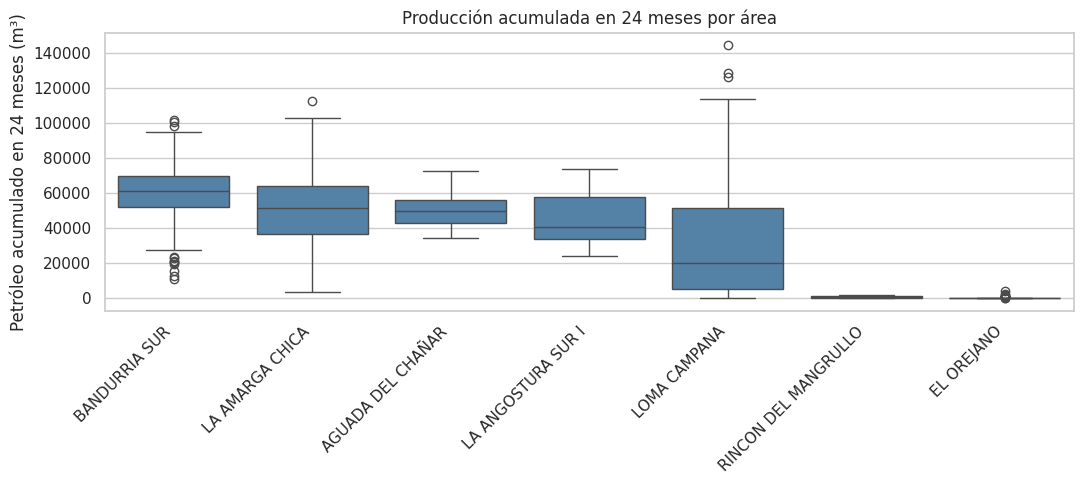

,pet_24m
area,
BANDURRIA SUR,60949.0
LA AMARGA CHICA,51201.0
AGUADA DEL CHAÑAR,49740.0
LA ANGOSTURA SUR I,40300.0
LOMA CAMPANA,20012.0
RINCON DEL MANGRULLO,354.0
EL OREJANO,4.0


In [73]:
area_por_pozo = db_ypf[["idpozo", "area"]].copy()
prod_24m_area = prod_24m.merge(area_por_pozo, on="idpozo", how="left")

prod_24m_area = prod_24m_area[prod_24m_area["area"].isin(areas_representativas)]

plt.figure(figsize=(11, 5))
orden = (
    prod_24m_area.groupby("area")["pet_24m"].median().sort_values(ascending=False).index
)
sns.boxplot(data=prod_24m_area, x="area", y="pet_24m", order=orden, color="steelblue")
plt.title("Producción acumulada en 24 meses por área")
plt.xlabel("")
plt.ylabel("Petróleo acumulado en 24 meses (m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

prod_24m_area.groupby("area")["pet_24m"].median().sort_values(ascending=False).round(0)

## 17. Hipótesis complementaria: interferencia entre pozos ("frac hits")
En los primeros 24 meses de un pozo no convencional es habitual que se perforen y fracturen pozos vecinos, ya que en Vaca Muerta la explotación avanza por locaciones (*pads*) con varios pozos próximos entre sí. Cuando eso ocurre, la fractura del pozo nuevo puede comunicarse con el reservorio del pozo existente y afectar su presión, generando una caída de producción que **no responde a la declinación natural** sino a esa interferencia. Esta sección explora, de forma descriptiva y asociativa, si existen pozos cuya producción cae de manera más pronunciada de lo esperable justo después de que se perforó un vecino cercano. **No se busca demostrar causalidad** — para eso haría falta un diseño más riguroso, con datos que hoy no tenemos (por ejemplo, presión de fondo de pozo) — sino identificar candidatos que ameriten una revisión más profunda en una etapa posterior del proyecto.

### 17.1 Distancia entre pozos
Se calcula la distancia entre cada par de pozos a partir de sus coordenadas geográficas, usando la fórmula de Haversine (distancia sobre la superficie terrestre, más apropiada que una resta simple de coordenadas cuando setrabaja en grados).
> Se asume que `coordenadax` y `coordenaday` corresponden a longitud y latitud en grados decimales.
Conviene confirmarlo contra el diccionario de datos antes de dar los resultados por definitivos.>

In [74]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia en kilómetros entre dos puntos dados en grados decimales."""
    radio_tierra_km = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radio_tierra_km * np.arcsin(np.sqrt(a))

In [75]:
# Una fila por pozo: coordenadas + fecha de inicio de perforación
ubicacion_pozos = (
    db_activos.groupby("idpozo")
    .agg(x=("coordenadax", "first"), y=("coordenaday", "first"))
    .join(db_ypf.set_index("idpozo")["adjiv_fecha_inicio_perf"])
    .dropna(subset=["x", "y", "adjiv_fecha_inicio_perf"])
)

print("Pozos con coordenadas y fecha de perforación válidas:", len(ubicacion_pozos))
ubicacion_pozos.head()

Pozos con coordenadas y fecha de perforación válidas: 1805


,x,y,adjiv_fecha_inicio_perf
idpozo,,,
134528,-68.911033,-38.405911,2010-01-28
135147,-68.798926,-38.302823,2010-09-04
135480,-68.869028,-38.298751,2010-11-12
135484,-68.631429,-38.357228,2010-10-23
135803,-68.788900,-38.456500,2011-01-23


In [76]:
RADIO_INTERFERENCIA_KM = 1.0  # radio de búsqueda de pozos vecinos; se puede ajustar y comparar

lat = ubicacion_pozos["y"].to_numpy()
lon = ubicacion_pozos["x"].to_numpy()

matriz_distancias = haversine_km(lat[:, None], lon[:, None], lat[None, :], lon[None, :])

ids = ubicacion_pozos.index.to_numpy()
i_idx, j_idx = np.where((matriz_distancias > 0) & (matriz_distancias <= RADIO_INTERFERENCIA_KM))

vecinos = pd.DataFrame({
    "idpozo": ids[i_idx],
    "idpozo_vecino": ids[j_idx],
    "distancia_km": matriz_distancias[i_idx, j_idx],
})
vecinos = vecinos.merge(
    ubicacion_pozos["adjiv_fecha_inicio_perf"].rename("fecha_perf_vecino"),
    left_on="idpozo_vecino", right_index=True,
).merge(
    ubicacion_pozos["adjiv_fecha_inicio_perf"].rename("fecha_perf_propia"),
    left_on="idpozo", right_index=True,
)

print("Pares de pozos vecinos dentro del radio:", len(vecinos))
print("Pozos con al menos un vecino:", vecinos["idpozo"].nunique())

Pares de pozos vecinos dentro del radio: 21884
Pozos con al menos un vecino: 1779


### 17.2 Eventos de interferencia potencial
Se considera un **evento de interferencia potencial** cuando un pozo vecino inicia su perforación **después** de que el pozo bajo análisis ya estaba en producción, y **dentro de sus primeros 24 meses**. Ese evento marca el mes de vida del pozo en el que, de existir interferencia, debería empezar a notarse.

In [77]:
eventos = vecinos[vecinos["fecha_perf_vecino"] > vecinos["fecha_perf_propia"]].copy()

eventos["mes_evento"] = (
    (eventos["fecha_perf_vecino"] - eventos["fecha_perf_propia"]).dt.days / 30.44
).round().astype(int)

eventos = eventos[eventos["mes_evento"].between(1, 24)]

print("Pozos con al menos un vecino perforado durante sus primeros 24 meses:",
      eventos["idpozo"].nunique())

# Nos quedamos con el evento más cercano por pozo y mes, para no contar dos veces
primer_evento_por_mes = (
    eventos.groupby(["idpozo", "mes_evento"])["distancia_km"].min().reset_index()
)
primer_evento_por_mes.head(10)

Pozos con al menos un vecino perforado durante sus primeros 24 meses: 1129


,idpozo,mes_evento,distancia_km
0,134528,10,0.773535
1,135147,10,0.827978
2,135147,12,0.856232
3,135147,20,0.803842
4,135484,12,0.952081
5,136060,11,0.865748
6,136060,16,0.874013
7,136060,21,0.898275
8,136381,12,0.834614
9,136381,13,0.641355


### 17.3 ¿La producción cae más de lo esperado alrededor de esos eventos?
Se calcula la variación porcentual de la producción de petróleo mes a mes, dentro de la ventana de los primeros 24 meses, y se compara la distribución de esa variación entre los meses **sin** evento reciente y los meses **con** un evento en los dos meses anteriores (se da un margen de un mes para que la interferencia se refleje en el registro).

In [78]:
serie_24m = (
    db_activos[db_activos["idpozo"].isin(pozos_con_24m) & (db_activos["mes_produccion"] <= 24)]
    .sort_values(["idpozo", "mes_produccion"])
    .copy()
)

serie_24m["prod_pet_mes_anterior"] = serie_24m.groupby("idpozo")["prod_pet"].shift(1)
serie_24m["variacion_pct"] = (
    (serie_24m["prod_pet"] - serie_24m["prod_pet_mes_anterior"])
    / serie_24m["prod_pet_mes_anterior"].replace(0, np.nan) * 100
)

# ¿Este mes cae dentro de la ventana de 0 a 2 meses posteriores a algún evento de interferencia?
eventos_por_pozo = primer_evento_por_mes.groupby("idpozo")["mes_evento"].apply(list).to_dict()

def tiene_evento_reciente(idpozo, mes):
    for mes_evento in eventos_por_pozo.get(idpozo, []):
        if mes_evento <= mes <= mes_evento + 2:
            return True
    return False

serie_24m["evento_vecino_reciente"] = [
    tiene_evento_reciente(p, m) for p, m in zip(serie_24m["idpozo"], serie_24m["mes_produccion"])
]

serie_24m["evento_vecino_reciente"].value_counts()

,count
evento_vecino_reciente,
False,25684
True,4792


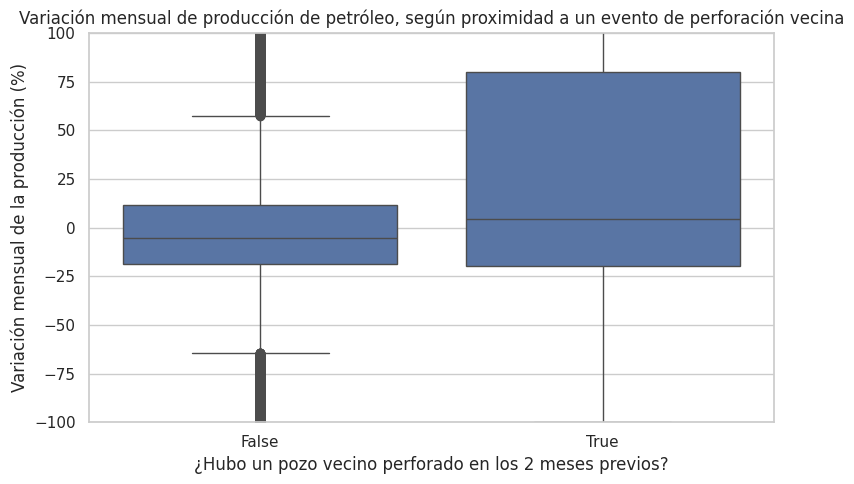

,count,mean,std,min,25%,50%,75%,max
evento_vecino_reciente,,,,,,,,
False,23163.0,3946.6,170762.5,-100.0,-18.8,-5.2,11.7,13482433.3
True,3621.0,20270.1,381183.4,-100.0,-19.5,4.3,79.8,15150600.0


In [79]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=serie_24m.dropna(subset=["variacion_pct"]),
            x="evento_vecino_reciente", y="variacion_pct")
plt.title("Variación mensual de producción de petróleo, según proximidad a un evento de perforación vecina")
plt.xlabel("¿Hubo un pozo vecino perforado en los 2 meses previos?")
plt.ylabel("Variación mensual de la producción (%)")
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()

serie_24m.groupby("evento_vecino_reciente")["variacion_pct"].describe().round(1)

Si la mediana y el rango de caída son notoriamente más negativos en el grupo con evento reciente, es un indicio afavor de la hipótesis. Si las distribuciones son similares, no hay evidencia de interferencia sistemática con esteradio y esta ventana temporal — lo cual también es un resultado válido para reportar.

### 17.4 Identificación de pozos candidatos
Se definen como **candidatos a interferencia** los meses en los que, habiendo un evento de perforación vecina reciente, la caída de producción es más pronunciada que la caída típica observada en los meses sin evento cercano(por debajo del percentil 10 de esa distribución de referencia).

In [80]:
umbral_caida_tipica = (
    serie_24m.loc[~serie_24m["evento_vecino_reciente"], "variacion_pct"].quantile(0.10)
)

print(f"Caída típica de referencia (percentil 10, meses sin evento cercano): {umbral_caida_tipica:.1f}%")

candidatos = serie_24m[
    serie_24m["evento_vecino_reciente"] &
    (serie_24m["variacion_pct"] < umbral_caida_tipica)
]

print("Meses candidatos a interferencia:", len(candidatos))
print("Pozos distintos involucrados:    ", candidatos["idpozo"].nunique())

candidatos[["idpozo", "fecha", "mes_produccion", "prod_pet",
            "prod_pet_mes_anterior", "variacion_pct"]].sort_values("variacion_pct").head(10)

Caída típica de referencia (percentil 10, meses sin evento cercano): -37.9%
Meses candidatos a interferencia: 522
Pozos distintos involucrados:     370


,idpozo,fecha,mes_produccion,prod_pet,prod_pet_mes_anterior,variacion_pct
18105,146979,2014-11-01,11,0.0,5.76,-100.0
18139,146980,2014-08-01,8,0.0,31.74,-100.0
18028,146977,2014-11-01,11,0.0,5.76,-100.0
104345,164644,2024-03-01,7,0.0,0.24,-100.0
42166,154187,2015-09-01,6,0.0,0.73,-100.0
42118,154185,2015-06-01,4,0.0,0.12,-100.0
72205,159221,2019-06-01,15,0.0,19.37,-100.0
69198,158424,2019-06-01,22,0.0,85.68,-100.0
72038,159219,2019-06-01,15,0.0,39.41,-100.0
72126,159220,2019-06-01,15,0.0,18.43,-100.0


### 17.5 Inspección visual de un caso
Se grafica la trayectoria de producción de un pozo candidato, marcando el mes en que se detectó el evento de perforación del vecino más cercano, a modo de verificación visual del patrón detectado en la tabla anterior.

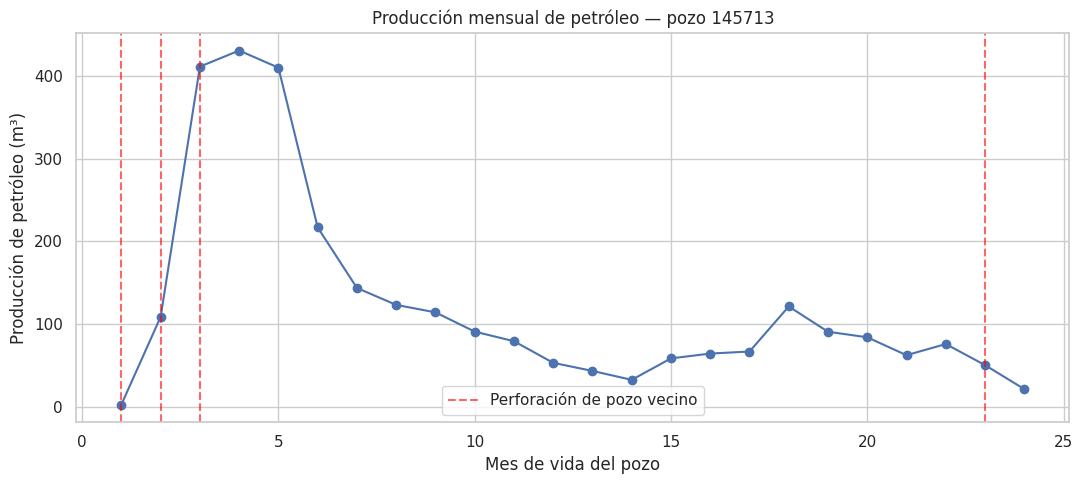

In [81]:
if len(candidatos) > 0:
    pozo_ejemplo = candidatos.iloc[0]["idpozo"]
    historia_pozo = serie_24m[serie_24m["idpozo"] == pozo_ejemplo]
    meses_evento_pozo = eventos_por_pozo.get(pozo_ejemplo, [])

    plt.figure(figsize=(11, 5))
    plt.plot(historia_pozo["mes_produccion"], historia_pozo["prod_pet"], marker="o")
    for mes_evento in meses_evento_pozo:
        plt.axvline(mes_evento, color="red", linestyle="--", alpha=0.6,
                    label="Perforación de pozo vecino" if mes_evento == meses_evento_pozo[0] else None)
    plt.title(f"Producción mensual de petróleo — pozo {pozo_ejemplo}")
    plt.xlabel("Mes de vida del pozo")
    plt.ylabel("Producción de petróleo (m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No se identificaron pozos candidatos con el radio y el umbral definidos. "
          "Conviene probar con un radio mayor (por ejemplo, 1.5 o 2 km).")

### 17.6 Limitaciones específicas de este análisis
- El resultado depende fuertemente del **radio elegido** (`RADIO_INTERFERENCIA_KM`) y de la **ventana temporal**  considerada; conviene repetir el análisis con al menos dos radios distintos antes de sacar conclusiones.
- Una caída de producción posterior a la perforación de un vecino puede deberse a otras causas no observadas aquí:  un paro programado, un cambio de sistema de extracción (sección 13) o un problema mecánico del propio pozo.
Este  análisis identifica **candidatos**, no confirma interferencia.
- Se asumió que `coordenadax` y `coordenaday` están en grados decimales; si estuvieran en otro sistema de coordenadas,  las distancias calculadas serían incorrectas y habría que ajustar la fórmula.
- La cantidad de pozos candidatos depende de cuántos pozos tienen coordenadas y fecha de perforación válidas; los  pozos con esos datos faltantes quedan fuera de este análisis y no del análisis de la sección 16.

## 18. Conclusiones de la primera entrega
>